## Importación de paquetes

In [1692]:
import os
import numpy as np                  # Importación de la biblioteca numpy para el manejo de arreglos
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import matplotlib.pyplot as plt     # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import seaborn as sns               # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
np.set_printoptions(
    suppress=True,
    linewidth=100,
    precision=2
)
plt.rcParams['figure.dpi'] = 120

## Funciones Auxiliares

### Gráfico de Barra

Función utilizada para la **generación de gráficos de barras**. Para su correcta ejecución, es necesario proporcionar los siguientes parámetros:

- *data_pandas*: conjunto de datos a representar gráficamente, almacenado en una estructura de tipo DataFrame de la librería pandas.

- *cols*: arreglo que contiene los nombres de las columnas que se desean graficar, definidos exactamente como aparecen en el DataFrame.

- *titulo*: cadena de caracteres utilizada para establecer el título del gráfico.

- *xlabel*: cadena de caracteres empleada para identificar la variable representada en el eje x.

- *ylabel*: cadena de caracteres empleada para identificar la variable representada en el eje y.

In [1693]:
def plot_grafico_barra(data_pandas, cols, titulo, xlabel, ylabel, ancho=7, alto=5):
    # Configuración general
    sns.set_theme(
        style="ticks",
        context="notebook",
        font_scale=1.0
    )

    # Dimensiones fijas
    FIG_WIDTH = ancho
    FIG_HEIGHT = alto

    # Selección correcta de columnas
    #cols = ['data', 'count']
    df =data_pandas.loc[:, cols]

    # Figura
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        dpi=120
    )

    # Gráfico correcto
    sns.barplot(
        data=df,
        x=cols[0],
        y=cols[1],
        palette='tab10',
        ax=ax,
        color='black'
    )

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Etiquetas
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación de etiquetas
    ax.tick_params(axis='x', rotation=45)

    # Valores sobre barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    # Cuadrícula elegante
    ax.grid(axis='y', linestyle='-', alpha=0.8)

    # Bordes limpios
    sns.despine()

    plt.tight_layout()
    plt.show()

## Obtención de la ruta del script

In [1694]:
os.getcwd()

'c:\\Users\\ernesto.molina\\Downloads'

## Importación de los datos

In [1695]:
file_name = 'loan-data.csv'     # Nombre del archivo que contiene los datos a procesar

## Procesamiento del formato de los datos extraídos

Durante esta etapa se llevan a cabo las siguientes actividades:

- Extracción de la información contenida en las bases de datos proporcionadas.

- Identificación y clasificación del tipo de dato presente en cada una de las variables que conforman el conjunto de datos.

- Segmentación de la base de datos original en dos grupos principales: 
    * datos categóricos y/o binarios
    * datos numéricos

    Esta segmentación se realiza con el propósito de aplicar posteriormente los procedimientos de limpieza y preprocesamiento adecuados para cada tipo de información.

### **Extracción de los datos proporcionados**

La carga de la información se realiza considerando todos los registros como cadenas de texto. La carga se realiza de esta manera para evitar la ocurrencia de errores durante el proceso de lectura y almacenamiento de los datos. 

Se emplea el punto y coma (`;`) como delimitador para separar los distintos campos contenidos en el conjunto de datos. La selección de este delimitador se definió a partir de analizar el formato de los datos crudos proporcionados.

In [1696]:
raw_data_np = np.loadtxt(file_name, delimiter=';', dtype='str')     # Carga de los datos proporcionados en formato de cadena de caracteres para realizar, a posteriori, la clasificación de su formato
raw_data_np = raw_data_np.transpose()                               # Conversión de columnas a filas para un mejor procesamiento de los datos para su clasificación y casteo
etiquetas = raw_data_np[:,0]                                        # Extracción de las etiquetas (primera fila de la base de datos)
data = raw_data_np[:,1:]                                            # Extracción de los datos (filas restantes de la base de datos a partir de la segunda)
print(etiquetas)
print(data[:,:5])

['id' 'issue_d' 'loan_amnt' 'loan_status' 'funded_amnt' 'term' 'int_rate' 'installment' 'grade'
 'sub_grade' 'verification_status' 'url' 'addr_state' 'total_pymnt']
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222

Como resultado del proceso de carga y extracción de información, se generan las siguientes estructuras de datos:

- `etiquetas`: arreglo que contiene los nombres de las variables o características presentes en el conjunto de datos original. Del análisis de los datos crudos proporcionados se identifica que estas etiquetas se encuentran registradas en la primera fila de la base de datos. Su función es describir cada atributo y facilitar la identificación e interpretación de la información almacenada.

- `data`: estructura que almacena los valores correspondientes a cada uno de los registros del conjunto de datos, manteniendo la asociación entre los datos y las etiquetas que los describen. Esta información está compuesta por todas las filas comprendidas entre la segunda y la última fila de la base de datos proporcionada.

### **Formato de los datos extraídos**

Una vez cargados los registros, se realiza un proceso de formateo de los datos con el objetivo de convertir cada elemento a un valor numérico de tipo punto flotante. 

Cuando un registro no puede convertirse debido a 

- incompatibilidades en su formato 

- presencia de valores faltantes

Se le asigna el valor especial `np.nan`, el cual permite identificar y gestionar posteriormente los datos no válidos o ausentes durante el análisis.

In [1697]:
data_numero = []
for i in data:
    temporal = []
    for j in i:
        try:
            x = float(j)
        except:
            x = np.nan
        finally:
            temporal.append(x)
    data_numero.append(temporal)
data_numero = np.array(data_numero)
print(data_numero[:,:5])

[[48010226.   57693261.   59432726.   53222800.   57803010.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [      13.33         nan         nan         nan       19.19]
 [    1184.86      938.57      494.86      300.35      296.78]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [    9452.96     4679.7      1969.83     1793.68     1178.51]]


Como resultado de este proceso se obtienen la siguiente variable:

- `data_numero`: conjunto de datos cuyos elementos han sido convertidos a valores numéricos de tipo punto flotante. Aquellos registros que no pudieron ser transformados debido a incompatibilidades en su formato se representan mediante el valor especial `np.nan`.

### **Clasificación de las agrupaciones de datos**

Se realiza un análisis de las variables que componen la base de datos con el propósito de identificar aquellas cuyos valores pueden representarse mediante datos numéricos. Para ello, se calcula el porcentaje de valores nulos resultantes respecto al total de registros disponibles.

A partir de este procedimiento se establecen los siguientes criterios:

* Si el porcentaje de valores nulos es igual al 100 %, se concluye que ninguno de los registros de la categoría pudo ser interpretado como un valor numérico, por lo que la variable se considera de naturaleza no numérica.
* Si el porcentaje de valores nulos es inferior al 100 %, se determina que la categoría contiene al menos algunos valores susceptibles de ser representados numéricamente.
* Si el porcentaje de valores nulos es mayor que 0 %, la categoría presenta registros que no pudieron convertirse a formato numérico o que originalmente correspondían a datos faltantes. En estos casos, podría ser necesario aplicar técnicas de limpieza e imputación durante las etapas posteriores del análisis.

Cabe destacar que la capacidad de una variable para representarse mediante valores numéricos no implica necesariamente que esta corresponda a una variable cuantitativa. En muchos conjuntos de datos existen categorías, etiquetas o identificadores que se encuentran codificados mediante números, aun cuando dichos valores no poseen un significado numérico desde el punto de vista analítico.

Por esta razón, la clasificación definitiva de una variable requiere analizar no solo el formato de los datos que contiene, sino también su propósito dentro del conjunto de datos y la naturaleza de la información que representa.

In [1698]:
cantidad_nulos = []
for i in data_numero:
    cantidad_nulos.append(int(pd.isna(i).sum()/len(i)*100))
index_categoricos, index_numericos = [], []
for i in range(len(cantidad_nulos)):
    if cantidad_nulos[i] == 100:
        index_categoricos.append(i)
    else:
        index_numericos.append(i)
print(index_numericos)
print(index_categoricos)

[0, 2, 4, 6, 7, 13]
[1, 3, 5, 8, 9, 10, 11, 12]


In [1699]:
print('Variables no numéricas')
for i in index_categoricos:
    print(etiquetas[i])

Variables no numéricas
issue_d
loan_status
term
grade
sub_grade
verification_status
url
addr_state


In [1700]:
print('Variables numéricas')
for i in index_numericos:
    print(etiquetas[i])

Variables numéricas
id
loan_amnt
funded_amnt
int_rate
installment
total_pymnt


#### **Visualización de los Datos Crudos**

In [1701]:
pd.DataFrame(data.transpose(), columns=etiquetas).head(15)

,id,issue_d,loan_amnt,loan_status,funded_amnt,term,int_rate,installment,grade,sub_grade,verification_status,url,addr_state,total_pymnt
0,48010226,May-15,35000.0,Current,35000.0,36 months,13.33,1184.86,C,C3,Verified,https://www.lendingclub.com/browse/loanDetail....,CA,9452.96
1,57693261,,30000.0,Current,30000.0,36 months,þëè.89,938.57,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,NY,4679.7
2,59432726,Sep-15,15000.0,Current,15000.0,36 months,íîå.53,494.86,B,B5,Verified,https://www.lendingclub.com/browse/loanDetail....,PA,1969.83
3,53222800,Jul-15,9600.0,Current,9600.0,36 months,þëè.89,300.35,A,A5,Not Verified,https://www.lendingclub.com/browse/loanDetail....,OH,1793.68
4,57803010,Aug-15,8075.0,Current,8075.0,36 months,19.19,296.78,,E3,Source Verified,https://www.lendingclub.com/browse/loanDetail....,TX,1178.51
5,63398019,Oct-15,14400.0,Current,14400.0,60 months,13.99,334.99,,C4,Not Verified,https://www.lendingclub.com/browse/loanDetail....,AL,681.17
6,60850626,Sep-15,,Current,13000.0,60 months,24.99,381.5,F,F4,Source Verified,https://www.lendingclub.com/browse/loanDetail....,CA,1126.45
7,46816139,Apr-15,7500.0,Current,7500.0,36 months,13.33,253.9,C,C3,,https://www.lendingclub.com/browse/loanDetail....,GA,2025.65
8,63918356,Nov-15,8000.0,Current,8000.0,36 months,þëè.89,250.29,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,MA,497.07
9,63651616,Nov-15,7200.0,Current,7200.0,36 months,äåê.59,241.18,C,C2,,https://www.lendingclub.com/browse/loanDetail....,TX,512.57


Existen diversas relaciones que pueden establecerse entre los valores contenidos en las variables que conforman la base de datos proporcionada:

* Se analiza la posible correlación entre las variables `loan_amnt` y `funded_amnt`, con el objetivo de evaluar la viabilidad de un proceso de imputación de valores ausentes en ambas columnas, en caso de existir una relación estadísticamente significativa entre ellas.

* Se identifica una relación directa entre la codificación de las variables `sub_grade` y `grade`, lo que permite considerar la posibilidad de realizar procesos de imputación cruzada en aquellos casos en los que se presenten valores faltantes en alguna de estas variables, aprovechando su correspondencia estructural.

#### **Observaciones**

La variable  `id` se encuentra representada mediante valores numéricos; sin embargo, su función dentro del conjunto de datos es actuar como identificador único de cada préstamo registrado. Por esta razón, aunque sus valores puedan interpretarse como datos numéricos desde el punto de vista del formato de almacenamiento, no constituyen una variable cuantitativa sobre la cual resulte apropiado realizar análisis estadísticos o aplicar operaciones aritméticas.

En consecuencia, esta variable se clasifica como un identificador y se excluye del conjunto de variables numéricas consideradas para el análisis. Alternativamente, puede integrarse dentro del grupo de variables categóricas o de identificación, preservando su utilidad para la trazabilidad de los registros.

In [1702]:
columna = 'id'
indice = list(etiquetas).index(columna)
index_numericos


[0, 2, 4, 6, 7, 13]

Se opta por conservar la columna `id` en los términos categóricos con el propósito de realizar posteriormente una operación de unión (merge) entre los conjuntos de datos categóricos y numéricos durante las etapas finales del proceso de preparación y consolidación de los datos.

In [1703]:
etiquetas[index_numericos]

array(['id', 'loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'total_pymnt'], dtype='<U69')

In [1704]:
index_categoricos.append(indice)
index_categoricos.sort()
index_categoricos

[0, 1, 3, 5, 8, 9, 10, 11, 12]

In [1705]:
etiquetas[index_categoricos]

array(['id', 'issue_d', 'loan_status', 'term', 'grade', 'sub_grade', 'verification_status', 'url',
       'addr_state'], dtype='<U69')

Como resultado de este proceso se obtienen las siguientes variables:

- `index_categoricos`: conjunto de índices asociados a variables categóricas y/o binarias.

- `index_numericos`: conjunto de índices asociados a variables de naturaleza numérica. Estas variables pueden ser utilizadas en análisis estadísticos.

### **Agrupamiento de datos categóricos**

In [1706]:
etiqueta_categoricos, data_categoricos = [], []
for i in index_categoricos:
    etiqueta_categoricos.append(etiquetas[i])
    data_categoricos.append(raw_data_np[i][1:])
data_categoricos = np.array(data_categoricos)
print(data_categoricos[:,:5])
print(etiqueta_categoricos)

[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222800'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57803010']
 ['CA' 'NY' 'PA' 'OH' 'TX']]
[np.str_('id'), np.str_('issue_d'), np.str_('loan_status'), np.str_('term'), np.str_('grade'), np.str_('sub_grade'), np.str_('verification_status'), np.str_('url'), np.str_('addr_state')]


### **Agrupamiento de datos numéricos**

In [1707]:
etiqueta_numericos, data_numericos = [], []
for i in index_numericos:
    etiqueta_numericos.append(etiquetas[i])
    data_numericos.append(raw_data_np[i][1:])
data_numericos = np.array(data_numericos)
print(data_numericos[:,:5])
print(etiqueta_numericos)

[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['9452.96' '4679.7' '1969.83' '1793.68' '1178.51']]
[np.str_('id'), np.str_('loan_amnt'), np.str_('funded_amnt'), np.str_('int_rate'), np.str_('installment'), np.str_('total_pymnt')]


## Procesamiento de datos categóricos

En esta sección se describe el proceso de análisis y preprocesamiento de los datos categóricos contenidos en la base de datos proporcionada. El objetivo de esta etapa es garantizar la calidad, consistencia e integridad de la información antes de su utilización en etapas posteriores del análisis.

El procedimiento incluye la identificación de valores faltantes, la detección de valores categóricos inconsistentes o mal asignados, así como la verificación de la presencia de valores duplicados en aquellas variables que, por su naturaleza, deben contener valores únicos.

Asimismo, se aplican técnicas de imputación para el tratamiento de valores faltantes dentro de las variables categóricas, y se realizan procesos de recategorización con el propósito de facilitar análisis segmentados y mejorar la interpretabilidad de los datos. Finalmente, se lleva a cabo la eliminación de variables o categorías redundantes que no aportan información relevante al análisis.

### **Cantidad de datos categóricos**

In [1708]:
print(len(etiqueta_categoricos))
print(etiqueta_categoricos)
data_categoricos_codificados, etiquetas_categoricos_codificados, columnas_numericas = [], [], []        # Inicialización de arreglos vacíos para almacenar los datos y las etiquetas asociados a variables categóricas y binarias procesadas.
print(data_categoricos[:,:5])

9
[np.str_('id'), np.str_('issue_d'), np.str_('loan_status'), np.str_('term'), np.str_('grade'), np.str_('sub_grade'), np.str_('verification_status'), np.str_('url'), np.str_('addr_state')]
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222800'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57803010']
 ['CA' 'NY' 'PA' 'OH' 'TX']]


### **Categoría: id**

In [1709]:
valor = 0

#### *Análisis de datos faltantes*

In [1710]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `id`, lo que indica que todos los elementos de esta columna contienen información válida y completa dentro del conjunto de datos analizado.

Esta verificación sugiere que la variable no presenta datos faltantes, por lo que no requiere la aplicación de técnicas de imputación en etapas posteriores del preprocesamiento.

#### *Análisis de datos duplicados*

El desarrollo de este análisis no es trivial, ya que los valores registrados en esta variable deben ser únicos. En caso de identificarse registros duplicados, es necesario aplicar un proceso de depuración para su eliminación, con el fin de garantizar la integridad y consistencia del conjunto de datos.

In [1711]:
print(f'Cantidad de valores únicos: {len(np.unique(data_categoricos[valor]))}')
print(f'Cantidad total de valores: {len(data_categoricos[valor])}')

Cantidad de valores únicos: 10000
Cantidad total de valores: 10000


Se observa que la cantidad de valores únicos coincide con el número total de registros presentes en la base de datos proporcionada. En consecuencia, no se identifican valores duplicados dentro de la variable analizada, lo que indica que cada registro es único.

In [1712]:
data_categoricos_codificados.append(np.array(data_categoricos[valor]))
etiquetas_categoricos_codificados.append('identificador')

### **Categoría: issue_d**

In [1713]:
valor = 1

#### *Análisis de datos faltantes*

In [1714]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `issue_d`, lo que indica que todos los elementos de esta columna contienen información válida y completa dentro del conjunto de datos analizado.

Esta verificación sugiere que la variable no presenta datos faltantes, por lo que no requiere la aplicación de técnicas de imputación en etapas posteriores del preprocesamiento.

#### *Exploración general de los datos*

In [1715]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la segunda columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'Apr-15' 'Aug-15' 'Dec-15' 'Feb-15' 'Jan-15' 'Jul-15' 'Jun-15' 'Mar-15' 'May-15' 'Nov-15'
 'Oct-15' 'Sep-15']
issue_d


Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.

#### *Cantidad de valores únicos*

In [1716]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'issue_d'

13


El análisis de esta variable revela la existencia de* **13** *categorías diferentes.

- De estas categorías*, **12** *se corresponden a los meses del año 2015, indicando el período temporal asociado a cada registro. 

- Por otra parte, la categoría restante agrupa aquellos registros para los cuales no se dispone de información, encontrándose representada mediante una etiqueta vacía. La presencia de esta última categoría evidencia la existencia de valores faltantes dentro de la variable analizada.

#### *Proceso de Codificación de Categorías*

*Inicialización de la lista que contiene los meses en orden cronológico. Esta lista es utilizada para realizar la codificación de la información contenida en la columna analizada en esta sección.*

In [1717]:
meses_ordenados = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dict_meses = {}
for i in range(len(meses_ordenados)):
    dict_meses[meses_ordenados[i]] = i
dict_meses

{'': 0,
 'Jan': 1,
 'Feb': 2,
 'Mar': 3,
 'Apr': 4,
 'May': 5,
 'Jun': 6,
 'Jul': 7,
 'Aug': 8,
 'Sep': 9,
 'Oct': 10,
 'Nov': 11,
 'Dec': 12}

*Codificación de los datos contenidos en la columna, y renombramiento de la columna para una mejor interpretación.*

In [1718]:
data_categoricos_codificados.append(np.array([dict_meses[data_categoricos[valor][i].split('-')[0]] for i in range(len(data_categoricos[valor]))]))
etiquetas_categoricos_codificados.append('fecha_prestamo')
columnas_numericas.append(etiquetas_categoricos_codificados[-1])

In [1719]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,identificador,fecha_prestamo
0,48010226,5
1,57693261,0
2,59432726,9
3,53222800,7
4,57803010,8
5,63398019,10
6,60850626,9
7,46816139,4
8,63918356,11
9,63651616,11


*La transformación de esta variable categórica se lleva a cabo mediante la asignación de valores numéricos a cada mes de registro, respetando su orden cronológico. Este procedimiento permite incorporar la naturaleza temporal de la variable en los análisis realizados.*

*Adicionalmente, se renombró la columna para proporcionar una descripción más representativa de su contenido y facilitar la interpretación de los resultados obtenidos.*

#### *Estructura de los Datos Modificados*

In [1720]:
pandas_date = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_date['porcentaje'] = pandas_date['count']/len(data_categoricos_codificados[-1])*100
pandas_date

,data,count,porcentaje
0,10,1095,10.95
1,7,1061,10.61
2,12,997,9.97
3,11,847,8.47
4,8,846,8.46
5,1,770,7.70
6,4,757,7.57
7,5,741,7.41
8,6,654,6.54
9,9,643,6.43


#### *Graficado de los Datos Proveidos*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


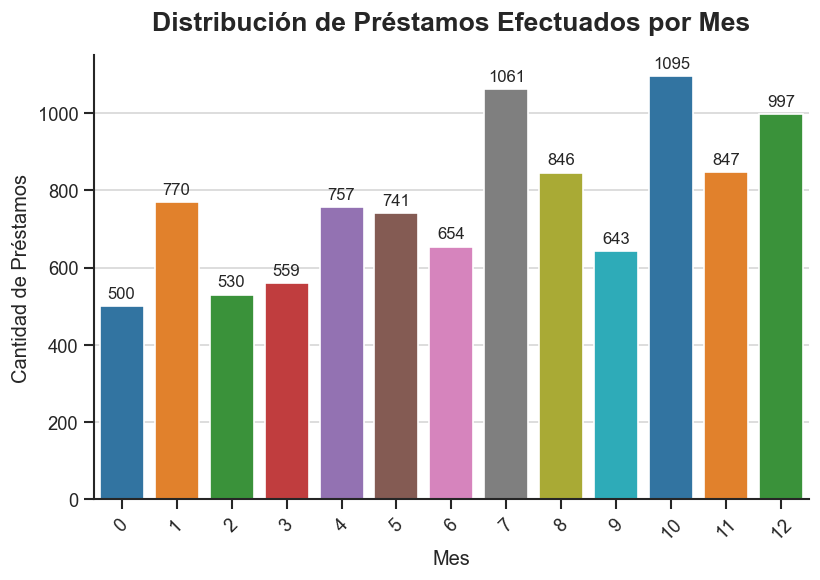

In [1721]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Mes',
    data_pandas=pandas_date,
    cols=['data', 'count'],
    xlabel='Mes',
    ylabel='Cantidad de Préstamos'
)

*En la gráfica se observa que durante el segundo semestre del período analizado se presentó un incremento en la cantidad de préstamos solicitados a las instituciones consideradas en el estudio, lo que sugiere una tendencia de crecimiento en la demanda de crédito en dicha etapa.*

#### 🧠 *Análisis Preliminar de la Distribución de Fechas de Depósito*

##### 📌 1. **Patrón principal (meses del año)**

Los valores están relativamente bien distribuidos entre los meses:

- El mes con mayor frecuencia es 10 -> Octubre (1095 casos)
- Le siguen 7 -> Julio (1061) y 12 -> Diciembre (997)
- El resto de meses se encuentran en un rango entre ~530 y ~850

👉 Esto sugiere que:

- No hay una fuerte estacionalidad extrema en la recolección de datos
- Aunque sí hay ligeras concentraciones en meses específicos (octubre, julio, diciembre)

##### ⚠️ 2. **Valor “0” (No especificado)**
- Frecuencia: 500 casos
- Representa un volumen importante (~equivalente a un mes completo)

👉 Esto es relevante porque:

- No es un valor marginal
- Puede afectar análisis temporales si no se trata adecuadamente
- Introduce incertidumbre en el componente temporal del dataset

No se recomienda realizar un proceso de imputación en los valores contenidos en esta variable

##### 📈 3. **Interpretación global**

En conjunto, la variable muestra:

- Distribución relativamente homogénea entre meses
- Leve concentración en ciertos meses (posible efecto operativo o de negocio)
- Presencia significativa de valores faltantes codificados como 0

##### ⚠️ 4. **Implicación analítica**

Si esta variable se usa en análisis temporal:

- ❌ No conviene tratarla como continua sin cuidado
- ❌ El “0” no debe interpretarse como mes real
- ✅ Debe tratarse como categoría especial o missing value

Opciones recomendadas:

- Separarlo como NaN o categoría “No especificado”
- Excluirlo en análisis de estacionalidad
- Mantenerlo solo para análisis de calidad de datos

##### ✍️ **Conclusión breve** (lista para informe)

La variable presenta una distribución relativamente uniforme entre los meses del año, con ligeras concentraciones en los meses 7, 10 y 12. Sin embargo, se observa la presencia de un valor codificado como 0, el cual corresponde a información no especificada y representa una proporción no despreciable del conjunto de datos, lo cual debe ser considerado en el análisis temporal para evitar interpretaciones sesgadas.

### **Categoría: loan_status**

In [1722]:
valor = 2

#### *Análisis de datos faltantes*

In [1723]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `loan_status`, lo que indica que todos los elementos de esta columna contienen información válida.

#### *Exploración general de los datos*

In [1724]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('loan_status')
print(etiqueta_categoricos[valor])

['' 'Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)']
loan_status


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos*

In [1725]:
print(np.unique(data_categoricos[valor]))

['' 'Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)']


*Las categorías integradas en esta columna son las siguientes:*
* **'Charged Off'**: *El préstamo ha sido clasificado como incobrable por la entidad financiera. Estado negativo para la institución financiera.*
* **'Current'**: *El préstamo se encuentra activo y los pagos se realizan conforme a lo establecido. Estado positivo para la institución financiera.*
* **'Default'**: *El préstamo ha entrado en incumplimiento de pago. Estado negativo para la institución financiera.*
* **'Fully Paid'**: *El préstamo fue liquidado en su totalidad. Estado positivo para la institución financiera.*
* **'In Grace Period'**: *El préstamo se encuentra dentro del período de gracia permitido para regularizar pagos atrasados.  Estado positivo para la instintución financiera.*
* **'Issued'**: *El préstamo ha sido aprobado y emitido recientemente. Se considera favorable debido a que no existe evidencia de incumplimiento al momento de la emisión del préstamo. Estado positivo para la institución financiera.*
* **'Late (16-30 days)'**: *El préstamo presenta un retraso en los pagos de entre 16 y 30 días. Aunque este estado refleja un retraso en el cumplimiento de las obligaciones de pago, se clasifica dentro de la categoría favorable debido a que el préstamo aún no ha alcanzado un nivel de morosidad severa y existe una probabilidad razonable de regularización por parte del cliente. Estado positivo para la institución financiera.*
* **'Late (31-120 days)'**: *El préstamo presenta un retraso en los pagos de entre 31 y 120 días. Este estado se considera como no favorable, puesto que existe una alto riesgo de que el cliente no realice los pagos de su deuda. Estado negativo para la institución financiera.*
* '': *Clasificación vacía. Debido a la ausencia de información que permita determinar el estado real del préstamo, estos registros se clasifican como no favorables bajo un criterio conservador de evaluación del riesgo. Estado negativo para la institución financiera.*

#### *Proceso de Rectificación de la Codificación de Categorías*

*Los datos categóricos originales se mantienen, asignando la etiqueta no definida como “No especificado”, ya que esta información puede resultar útil en análisis posteriores que requieran una segmentación más detallada de los distintos estados registrados.*

In [1726]:
data_categoricos_codificados.append(np.array([i if i != '' else np.str_('No especificado') for i in data_categoricos[valor]]))    # Recategorización del estado no especificado en los datos crudos proporcionados
etiquetas_categoricos_codificados.append('estado_prestamo')                                                             # Renombramiento de la categoría para una mejor interpretación

#### *Estructura de los Datos Modificados*

In [1727]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,identificador,fecha_prestamo,estado_prestamo
0,48010226,5,Current
1,57693261,0,Current
2,59432726,9,Current
3,53222800,7,Current
4,57803010,8,Current
5,63398019,10,Current
6,60850626,9,Current
7,46816139,4,Current
8,63918356,11,Current
9,63651616,11,Current


In [1728]:
pandas_estado = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_estado['porcentaje'] = pandas_estado['count']/len(data_categoricos_codificados[-1])*100
pandas_estado

,data,count,porcentaje
0,Current,8538,85.38
1,Fully Paid,505,5.05
2,No especificado,500,5.00
3,Issued,184,1.84
4,Late (31-120 days),115,1.15
5,Charged Off,61,0.61
6,In Grace Period,56,0.56
7,Late (16-30 days),30,0.30
8,Default,11,0.11


*La distribución resulta altamente informativa, ya que permite observar de forma directa la estructura de riesgo de la cartera, así como posibles inconsistencias o problemas de calidad en los datos.*

#### *Graficado de la Distribución de los Estados de los Préstamos*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


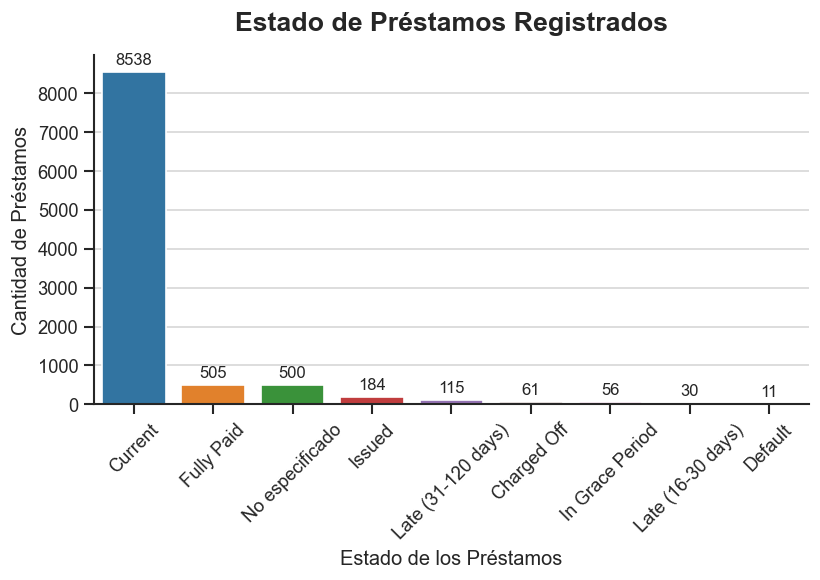

In [1729]:
plot_grafico_barra(
    titulo='Estado de Préstamos Registrados',
    data_pandas=pandas_estado,
    cols=['data', 'count'],
    xlabel='Estado de los Préstamos',
    ylabel='Cantidad de Préstamos'
)

*Se observa una alta asimetría en la distribución de los préstamos según su estado, con una clara predominancia de aquellos clasificados como “al corriente”, los cuales superan ampliamente en frecuencia al resto de categorías definidas. Asimismo, destaca la presencia significativa de registros en la categoría “No especificado”, cuya magnitud resulta superior a la mayoría de los estados restantes, a excepción de los préstamos “Current” y “Fully Paid”. Esta situación sugiere la existencia de una posible pérdida de información o limitaciones en la clasificación de los datos, lo cual podría influir en la interpretación global de la cartera.*

#### 🧠 *Análisis Preliminar de la Distribución de Categorías de Estados de Cuenta*

##### Análisis de los Estados *Saludables* (*Current, Fully Paid, Issued*)

In [1730]:
print((8538 + 505 + 184)/len(data_categoricos_codificados[-1])*100)

92.27


*Estados **buenos** o saludables* - 92.27 %

🟢 Current (8538) → domina ampliamente la distribución

✅ Fully Paid (505) → préstamos cerrados de forma exitosa

🆕 Issued (184) → préstamos recientemente emitidos, sin historial de comportamiento aún

En conjunto, la cartera se encuentra fuertemente concentrada en préstamos activos y, en su mayoría, con un comportamiento saludable. 

Los estados considerados “buenos” representan aproximadamente el 92.27 % del total de préstamos otorgados, en términos absolutos.

##### Análisis de los Estados *Intermedios* (*In Grace Period, Late (16-30 days)*)

In [1731]:
print((56 + 30)/len(data_categoricos_codificados[-1])*100)

0.86


*Estados intermedios (zona de alerta)* - 0.86 %

🟡 In Grace Period (56) → préstamos dentro del período de gracia, con posibilidad de regularización sin consecuencias mayores.

⚠️ Late (16–30 days) (30) → préstamos con retrasos iniciales en los pagos, considerados una señal temprana de posible deterioro crediticio.

Estos estados representan una zona de riesgo moderado, ya que reflejan clientes que han comenzado a presentar dificultades de pago, pero que aún cuentan con una alta probabilidad de recuperación mediante acciones de seguimiento oportunas.

📊 En conjunto, los estados financieros intermedios representan aproximadamente el 0.86 % del total de préstamos otorgados, por lo que su incidencia dentro de la cartera es relativamente baja en términos absolutos.

##### Análisis de los Estados de *Alto Riesgo* (*Default, Charged Off, Late (31-120 days)*)

In [1732]:
print((115 + 11 + 61)/len(data_categoricos_codificados[-1])*100)

1.87


*Estados de alto riesgo o pérdida* - 1.87 %

🔴 Late (31–120 days) (115) → préstamos con retrasos significativos en los pagos, lo que indica una alta probabilidad de incumplimiento.

⛔ Default (11) → préstamos en situación de incumplimiento, donde el prestatario ha dejado de cumplir con sus obligaciones de pago.

💸 Charged Off (61) → préstamos considerados como pérdidas por la institución financiera, tras agotar las acciones de recuperación correspondientes.

Estos estados reflejan un deterioro significativo de la calidad crediticia de la cartera, ya que corresponden a préstamos con un elevado riesgo de impago o que han sido clasificados directamente como pérdidas.

📉 En conjunto, los estados financieros de alto riesgo o pérdida representan aproximadamente el 1.87 % del total de préstamos otorgados, por lo que, aunque su proporción es reducida, constituyen el segmento de mayor interés para los análisis de riesgo crediticio y la construcción de modelos predictivos de incumplimiento.

##### Análisis de los Estados *No Especificados*

In [1733]:
print((500)/len(data_categoricos_codificados[-1])*100)

5.0


*Categoría "No especificado" (500 casos)* - 5 %

Esta categoría constituye un punto de especial interés dentro del análisis, ya que representa la tercera categoría con mayor frecuencia en el conjunto de datos. 

Su volumen es comparable al de estados relevantes como Fully Paid, por lo que no puede considerarse un conjunto residual o insignificante.

⚠️ Es la tercera categoría más numerosa del conjunto de datos.

📊 Su frecuencia es cercana a la observada en préstamos Fully Paid.

🔍 Puede introducir sesgos en los análisis estadísticos y en la construcción de modelos predictivos si no se trata adecuadamente.

🧹 Sugiere la existencia de información faltante o inconsistencias en el proceso de recopilación y almacenamiento de los datos.

La presencia de esta categoría puede estar asociada a diferentes factores:

💡 Debido a su tamaño relativo, se recomienda conservar esta categoría durante las etapas iniciales del análisis exploratorio y evaluar posteriormente su comportamiento respecto a las demás variables. Esto permitirá determinar si corresponde a un patrón específico de clientes o préstamos, o si se trata únicamente de registros con información incompleta.

##### Conclusiones del Análisis Preliminar

Se puede considerar la creación de una segunda variable categórica que agrupe los estados de los préstamos según su nivel de riesgo. Esta clasificación permitiría desarrollar segmentaciones más específicas en análisis posteriores, facilitando la evaluación del estado financiero de la institución y la identificación de distintos niveles de exposición al riesgo crediticio.

Esta nueva categorización puede corresponderse con la siguiente:

- **'No Especificado'**

- **'Bajo'**

- **'Intermedio'**

- **'Alto'**

In [1734]:
dict_riesgo = {
    'Bajo' : ['Current', 'Fully Paid', 'Issued'],
    'Intermedio' : ['In Grace Period', 'Late (16-30 days)'],
    'Alto' : ['Default', 'Charged Off', 'Late (31-120 days)']
}

In [1735]:
keys_dict = dict_riesgo.keys()
temporal_categoria = []
for i in data_categoricos_codificados[-1]:
    if i != 'No especificado':
        for k in keys_dict:
            if i in dict_riesgo[k]:
                temporal_categoria.append(k)
                break
    else:
        temporal_categoria.append(str(i))

In [1736]:
data_categoricos_codificados.append(np.array(temporal_categoria))
etiquetas_categoricos_codificados.append('riesgo_prestamo')    

In [1737]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo
0,48010226,5,Current,Bajo
1,57693261,0,Current,Bajo
2,59432726,9,Current,Bajo
3,53222800,7,Current,Bajo
4,57803010,8,Current,Bajo
5,63398019,10,Current,Bajo
6,60850626,9,Current,Bajo
7,46816139,4,Current,Bajo
8,63918356,11,Current,Bajo
9,63651616,11,Current,Bajo


A partir de la distribución observada, es posible identificar los siguientes patrones:

- La distribución asociada a los diferentes estados del préstamo presenta un marcado desbalance entre categorías (Fuerte desbalance de clases (muy relevante metodológicamente)).

- Existe un claro predominio de los préstamos clasificados en estado Current, lo que indica que la mayor parte de los créditos se encuentran activos y al corriente en sus obligaciones de pago (Una cartera mayoritariamente sana o activa).

- Los estados asociados a riesgos intermedios y altos niveles de morosidad presentan una frecuencia de ocurrencia considerablemente menor, por lo que constituyen eventos poco frecuentes dentro del conjunto de datos (Baja proporción de riesgo).

- Se identifica una categoría correspondiente a registros con información no especificada (No especificado), cuya frecuencia es superior a la observada en varias de las categorías asociadas a riesgo crediticio. Debido a su magnitud, esta categoría puede introducir sesgos relevantes en análisis posteriores, particularmente en aquellos relacionados con la caracterización del riesgo y la construcción de modelos predictivos (Presencia no despreciable de datos incompletos).

In [1738]:
pandas_riesgo = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_riesgo['porcentaje'] = pandas_riesgo['count']/len(data_categoricos_codificados[-1])*100
pandas_riesgo

,data,count,porcentaje
0,Bajo,9227,92.27
1,No especificado,500,5.00
2,Alto,187,1.87
3,Intermedio,86,0.86


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


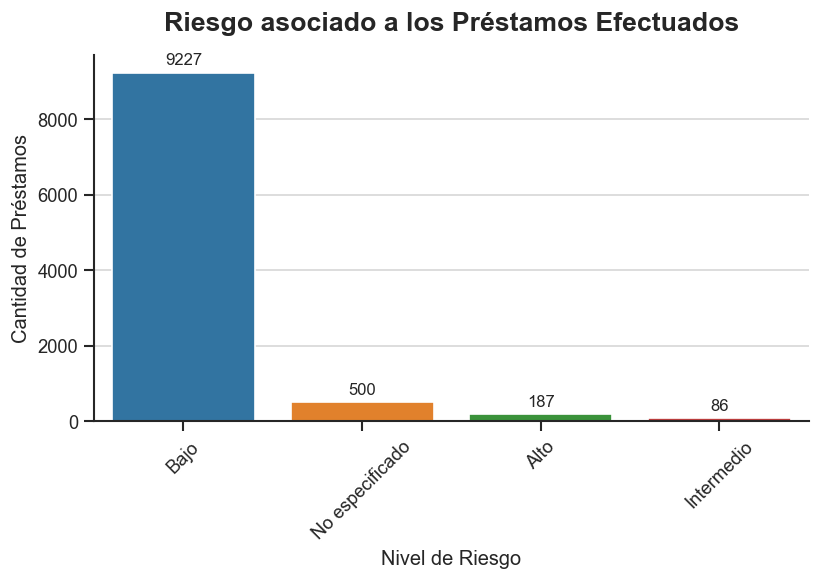

In [1739]:
plot_grafico_barra(
    titulo='Riesgo asociado a los Préstamos Efectuados',
    data_pandas=pandas_riesgo,
    cols=['data', 'count'],
    xlabel='Nivel de Riesgo',
    ylabel='Cantidad de Préstamos'
)

*Se observa que el nivel de riesgo asociado a la cartera de la institución financiera es relativamente bajo en términos de la proporción de préstamos clasificados dentro de las categorías de riesgo. No obstante, la categoría “No especificado” presenta una magnitud superior a la de los préstamos de riesgo medio y alto, lo cual constituye un punto crítico en el análisis. Esta situación sugiere la posible introducción de sesgos en la interpretación de la distribución de riesgo, en caso de no realizarse una adecuada segmentación o tratamiento de los registros que no han sido correctamente identificados.*

#### *Proceso de Conversión de la Categoría a Binario*  (Imputación de Valores Ausentes)

*Para facilitar el análisis del estado financiero de la institución, se realiza una transformación de los datos categóricos asociados al estado del préstamo en una representación binaria, donde cada registro se clasifica de acuerdo con su condición positiva o negativa para la entidad financiera.*

In [1740]:
print(np.unique(data_categoricos_codificados[-2]))
condicion_positiva = ['Current', 'Fully Paid', 'In Grace Period', 'Issued', 'Late (16-30 days)']

['Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)' 'No especificado']


In [1741]:
data_categoricos_codificados.append(np.array(['Positivo' if i in condicion_positiva else 'Negativo' for i in data_categoricos[valor]]))    # Recategorización del estado no especificado en los datos crudos proporcionados
etiquetas_categoricos_codificados.append('clasificacion_estado_prestamo')   

In [1742]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo
0,48010226,5,Current,Bajo,Positivo
1,57693261,0,Current,Bajo,Positivo
2,59432726,9,Current,Bajo,Positivo
3,53222800,7,Current,Bajo,Positivo
4,57803010,8,Current,Bajo,Positivo
5,63398019,10,Current,Bajo,Positivo
6,60850626,9,Current,Bajo,Positivo
7,46816139,4,Current,Bajo,Positivo
8,63918356,11,Current,Bajo,Positivo
9,63651616,11,Current,Bajo,Positivo


*La recategorización de esta variable a una variable binaria se llevó a cabo de manera adecuada, la cual clasifica el estado del préstamo como positivo (1) o negativo (0) para la institución financiera.*

In [1743]:
pandas_estado_prestamo = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_estado_prestamo['porcentaje'] = pandas_estado_prestamo['count']/len(data_categoricos_codificados[-1])*100
pandas_estado_prestamo

,data,count,porcentaje
0,Positivo,9313,93.13
1,Negativo,687,6.87


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


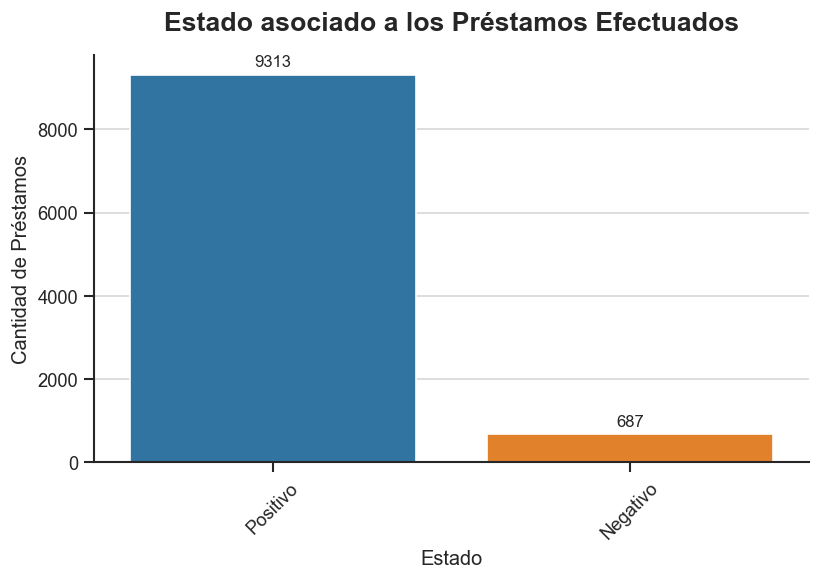

In [1744]:
plot_grafico_barra(
    titulo='Estado asociado a los Préstamos Efectuados',
    data_pandas=pandas_estado_prestamo,
    cols=['data', 'count'],
    xlabel='Estado',
    ylabel='Cantidad de Préstamos'
)

*La mayoría de los préstamos efectuados presentan un estado favorable, lo cual, en términos relativos al total de operaciones registradas, sugiere una gestión generalmente adecuada por parte de las instituciones financieras. Este resultado debe interpretarse con cautela, ya que se ha adoptado una perspectiva conservadora al considerar los préstamos no categorizados dentro del balance negativo de la institución. Esta decisión puede influir en la evaluación global del desempeño crediticio y en la estimación del nivel real de riesgo asociado a la cartera.*

### **Categoría: term**

In [1745]:
valor = 3

#### *Análisis de datos faltantes*

In [1746]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `term`, lo que indica que todos los elementos de esta columna contienen información válida.

#### *Exploración general de los datos*

In [1747]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' ' 36 months' ' 60 months']
term


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos*

In [1748]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'issue_d'

3


Las categorías presentes en esta columna son las siguientes:

* '36 months': préstamo con una duración establecida de 36 meses.
* '60 months': préstamo con una duración establecida de 60 meses.
* '': valor vacío que representa la ausencia de información sobre el plazo de duración del préstamo.

Se debe realizar una mejora en el formato de la categoría establecida en esta columnas, de manera que la cadena de caracteres no posea espacios injustificados a su derecha e izquierda. Posteriormente, se puede extraer el número de meses en los cuales se acordó el préstamo, para simplificar la información a la mínima requerida. La etiqueta vacía, con tal de no perder la información, se recomienda modificar con una etiqueta de no especificado.

Para cuestión relacionada al desarrollo de estudios del estado financiero de la institución, se recomienda modificar los valores no especificado al máximo valor registrado en los datos proporcionados (60 meses), para que dicha información sea incluida en el análisis.

#### *Proceso de Corrección de los Valores incluidos en la Categoría*

In [1749]:
list_char = np.char.split(np.char.strip(data_categoricos[valor]), ' ')
temporal = [int(i[0]) if len(i)>0 and i[0] != '' else 'No especificado' for i in list_char]
data_categoricos_codificados.append(temporal)
etiquetas_categoricos_codificados.append('duracion_prestamo_meses')
columnas_numericas.append(etiquetas_categoricos_codificados[-1])

#### *Estructura de los Datos Modificados*

In [1750]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(10)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses
0,48010226,5,Current,Bajo,Positivo,36
1,57693261,0,Current,Bajo,Positivo,36
2,59432726,9,Current,Bajo,Positivo,36
3,53222800,7,Current,Bajo,Positivo,36
4,57803010,8,Current,Bajo,Positivo,36
5,63398019,10,Current,Bajo,Positivo,60
6,60850626,9,Current,Bajo,Positivo,60
7,46816139,4,Current,Bajo,Positivo,36
8,63918356,11,Current,Bajo,Positivo,36
9,63651616,11,Current,Bajo,Positivo,36


#### *Graficado de la Distribución de los Estados de los Préstamos*

In [1751]:
pandas_termino = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_termino['porcentaje'] = pandas_termino['count']/len(data_categoricos_codificados[-1])*100
pandas_termino

,data,count,porcentaje
0,36,6281,62.81
1,60,3219,32.19
2,No especificado,500,5.00


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


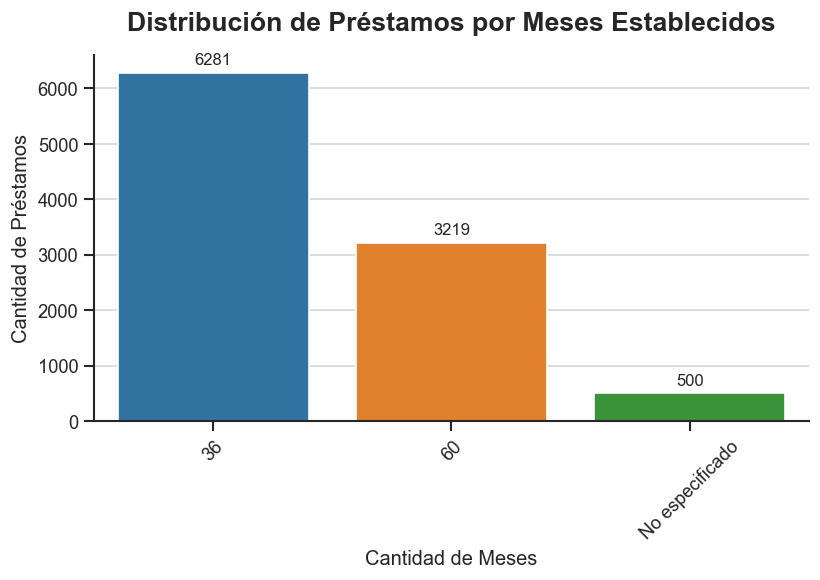

In [1752]:
plot_grafico_barra(
    titulo='Distribución de Préstamos por Meses Establecidos',
    data_pandas=pandas_termino,
    cols=['data', 'count'],
    xlabel='Cantidad de Meses',
    ylabel='Cantidad de Préstamos'
)

*Se observa un predominio de préstamos con plazo de amortización de 36 meses, seguido de aquellos con una duración de 60 meses. Asimismo, se identifica la presencia de registros con información faltante respecto al plazo del préstamo.*

*Dado que esta última categoría representa una proporción reducida dentro del conjunto de datos, su influencia en la distribución global es limitada. Por ello, el tratamiento de estos valores puede abordarse mediante estrategias de imputación o reasignación a las categorías existentes, considerando criterios definidos en función del objetivo del análisis o del modelo a desarrollar.*

In [1753]:
temporal = [float(i) if i != 'No especificado' else np.nan for i in data_categoricos_codificados[-1]]
data_categoricos_codificados[-1] = np.array(temporal)

Se realiza esta modificación para realizar posteriormente un proceso de imputación más robusto en el que se evalúe las condiciones establecidas para el préstamo, en el cual se tenga en cuenta el monto aceptado por la institución, la tasa de interés acordada y el pago mensual que debe ser efectuado por el cliente

#### *Imputación Absoluta de los Datos Ausentes*

Esta imputación se realiza de manera que el préstamo se haya efectuado por 60 meses en cada uno de los casos donde se presenten datos ausentes, así se consideran condiciones adversas para la salud financiera de la institución en cuestión.

In [1754]:
arr = np.array(data_categoricos_codificados[-1])
data_categoricos_codificados.append(np.array((np.where(np.isnan(arr), float('60'), arr))))
etiquetas_categoricos_codificados.append('duracion_prestamo_meses_imputados')
columnas_numericas.append(etiquetas_categoricos_codificados[-1])

In [1755]:
pandas_termino_imputado = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_termino_imputado['porcentaje'] = pandas_termino_imputado['count']/len(data_categoricos_codificados[-1])*100
pandas_termino_imputado

,data,count,porcentaje
0,36.0,6281,62.81
1,60.0,3719,37.19


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


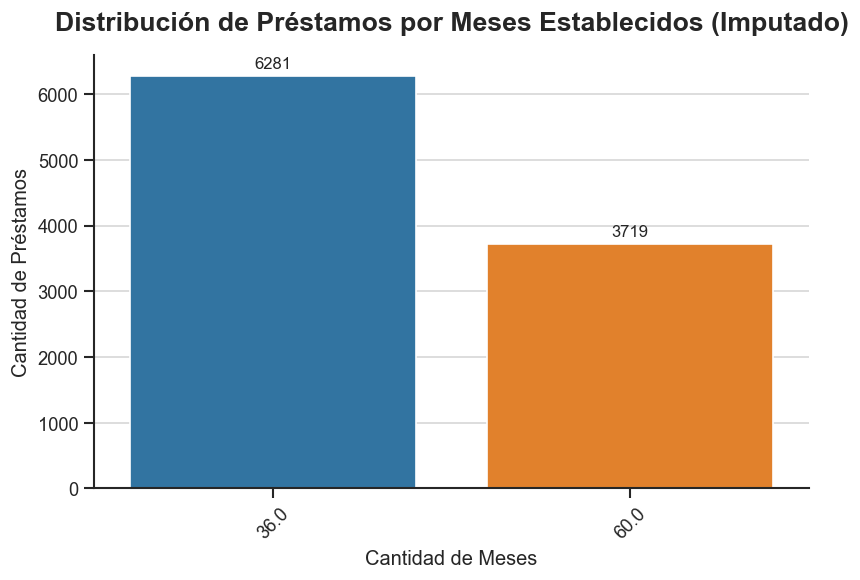

In [1756]:
plot_grafico_barra(
    titulo='Distribución de Préstamos por Meses Establecidos (Imputado)',
    data_pandas=pandas_termino_imputado,
    cols=['data', 'count'],
    xlabel='Cantidad de Meses',
    ylabel='Cantidad de Préstamos'
)

#### *Estructura de los Datos Modificados*

In [1757]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(5)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados
0,48010226,5,Current,Bajo,Positivo,36.0,36.0
1,57693261,0,Current,Bajo,Positivo,36.0,36.0
2,59432726,9,Current,Bajo,Positivo,36.0,36.0
3,53222800,7,Current,Bajo,Positivo,36.0,36.0
4,57803010,8,Current,Bajo,Positivo,36.0,36.0


Los datos se reorganizan de manera que cada elemento del arreglo corresponda a una de las columnas del conjunto de datos original. Esta transformación se realiza con el propósito de facilitar la identificación y el análisis de posibles valores erróneos, inconsistentes o atípicos presentes en los registros.

### **Categorías: grade y sub-grade**

In [1758]:
valor = 4
temporal_grado = []

#### *Análisis de datos faltantes (grados)*

In [1759]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `term`, lo que indica que todos los elementos de esta columna contienen información válida.

#### *Exploración general de los datos (grados)*

In [1760]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'A' 'B' 'C' 'D' 'E' 'F' 'G']
grade


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos (grados)*

In [1761]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'grade'

8


Las categorías presentes en esta columna se corresponden a una codificación del grado de riesgo identificado por parte de la institución financiera, que escala desde la categoría A (correspondiente al menor riesgo) hasta la categoría G (correspondiente al mayor riesgo). Se incluye una etiqueta vacía, la cual puede deberse a datos faltantes cuando se registraró el grado de los préstamos efectuados.

Se debe realizar una mejora en los datos proporcionados  en el formato de la categoría establecida en esta columnas, de manera que la cadena de caracteres no posea espacios injustificados a su derecha e izquierda. Posteriormente, se puede extraer el número de meses en los cuales se acordó el préstamo, para simplificar la información a la mínima requerida. La etiqueta vacía, con tal de no perder la información, se recomienda modificar con una etiqueta de no especificado.

Para cuestión relacionada al desarrollo de estudios del estado financiero de la institución, se recomienda modificar los valores no especificado al máximo valor registrado en los datos proporcionados (60 meses), para que dicha información sea incluida en el análisis.

#### *Carga de Datos (grados)*

Almacenamiento de los valores correspondientes a la variable `grade`

In [1762]:
temporal_grado.append(data_categoricos[valor])

In [1763]:
valor = 5

#### *Análisis de datos faltantes (sub-grados)*

In [1764]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `term`, lo que indica que todos los elementos de esta columna contienen información válida.

#### *Exploración general de los datos (sub-grados)*

In [1765]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4' 'C5' 'D1' 'D2' 'D3' 'D4'
 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3' 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']
sub_grade


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos (sub-grados)*

In [1766]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'grade'

36


Las categorías presentes en esta columna se corresponden a una codificación del grado de riesgo identificado por parte de la institución financiera, que escala desde la categoría A1 (correspondiente al menor riesgo) hasta la categoría G5 (correspondiente al mayor riesgo). Se incluye una etiqueta vacía, la cual puede deberse a datos faltantes cuando se registraró el grado de los préstamos efectuados.

Se debe realizar una mejora en los datos proporcionados  en el formato de la categoría establecida en esta columnas, de manera que la cadena de caracteres no posea espacios injustificados a su derecha e izquierda. Posteriormente, se puede extraer el número de meses en los cuales se acordó el préstamo, para simplificar la información a la mínima requerida. La etiqueta vacía, con tal de no perder la información, se recomienda modificar con una etiqueta de no especificado.

Para cuestión relacionada al desarrollo de estudios del estado financiero de la institución, se recomienda modificar los valores no especificado al máximo valor registrado en los datos proporcionados (60 meses), para que dicha información sea incluida en el análisis.

#### *Carga de Datos (sub-grados)*

Almacenamiento de los valores correspondientes a la variable `grade`

In [1767]:
temporal_grado.append(data_categoricos[valor])

In [1768]:
for i in range(len(temporal_grado)):
    temporal_grado[i] = np.where(
        temporal_grado[i] == '',
        'N',
        temporal_grado[i]
    )

#### *Visualizacion datos*

In [1769]:
pd.DataFrame(np.array(temporal_grado).transpose(), columns=['grado', 'sub_grado']).head(10)

,grado,sub_grado
0,C,C3
1,A,A5
2,B,B5
3,A,A5
4,N,E3
5,N,C4
6,F,F4
7,C,C3
8,A,A5
9,C,C2


Determinar la cantidad de valores no especificados en la categoría grado y sub-grado

In [1770]:
pandas_grado = pd.Series(temporal_grado[-2]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_grado['porcentaje'] = pandas_grado['count']/len(temporal_grado[-2])*100
pandas_grado

,data,count,porcentaje
0,C,2766,27.66
1,B,2606,26.06
2,A,1632,16.32
3,D,1389,13.89
4,E,816,8.16
5,N,515,5.15
6,F,236,2.36
7,G,40,0.40


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


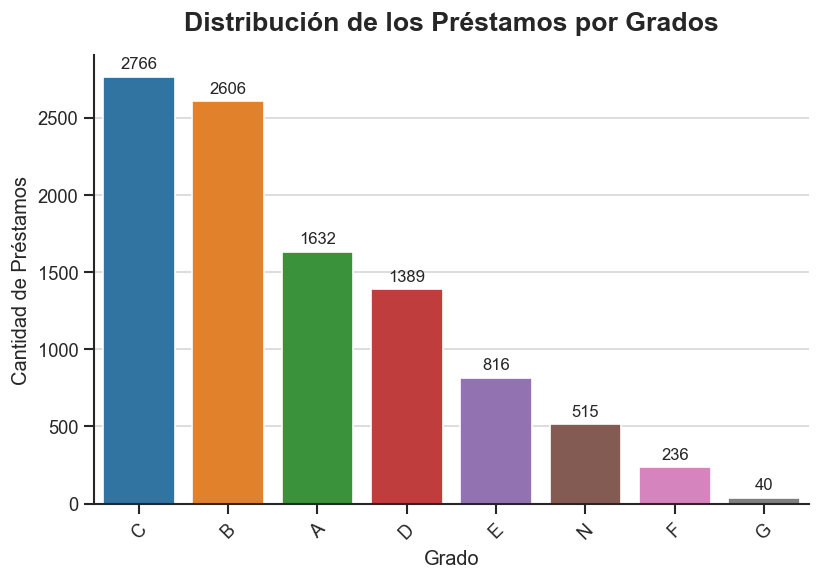

In [1771]:
plot_grafico_barra(
    data_pandas=pandas_grado,
    cols=['data', 'count'],
    titulo='Distribución de los Préstamos por Grados',
    xlabel='Grado',
    ylabel='Cantidad de Préstamos'
)

Se observa que la mayor parte de los préstamos se concentra en las categorías B y C, las cuales presentan 2606 y 2766 registros, respectivamente. En contraste, las categorías F y G contienen una cantidad considerablemente menor de préstamos, con 236 y 40 registros.

Asimismo, se identifica la categoría N, correspondiente a registros sin una clasificación de grado definida. Esta categoría agrupa 515 préstamos, lo que representa una proporción no despreciable del conjunto de datos. La presencia de estos registros sugiere la existencia de información faltante o no especificada en la variable grade, por lo que resulta conveniente considerar su tratamiento durante las etapas de limpieza y preprocesamiento de datos.

En términos generales, la distribución evidencia una mayor concentración de préstamos en categorías de riesgo intermedio, mientras que los grados asociados a perfiles de mayor riesgo presentan una frecuencia significativamente menor.

In [1772]:
pandas_subgrado = pd.Series(temporal_grado[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_subgrado['porcentaje'] = pandas_subgrado['count']/len(temporal_grado[-1])*100
pandas_subgrado

,data,count,porcentaje
0,C1,629,6.29
1,C3,586,5.86
2,C2,567,5.67
3,C4,564,5.64
4,B4,553,5.53
5,B3,530,5.30
6,B2,517,5.17
7,N,514,5.14
8,B1,509,5.09
9,A5,502,5.02


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


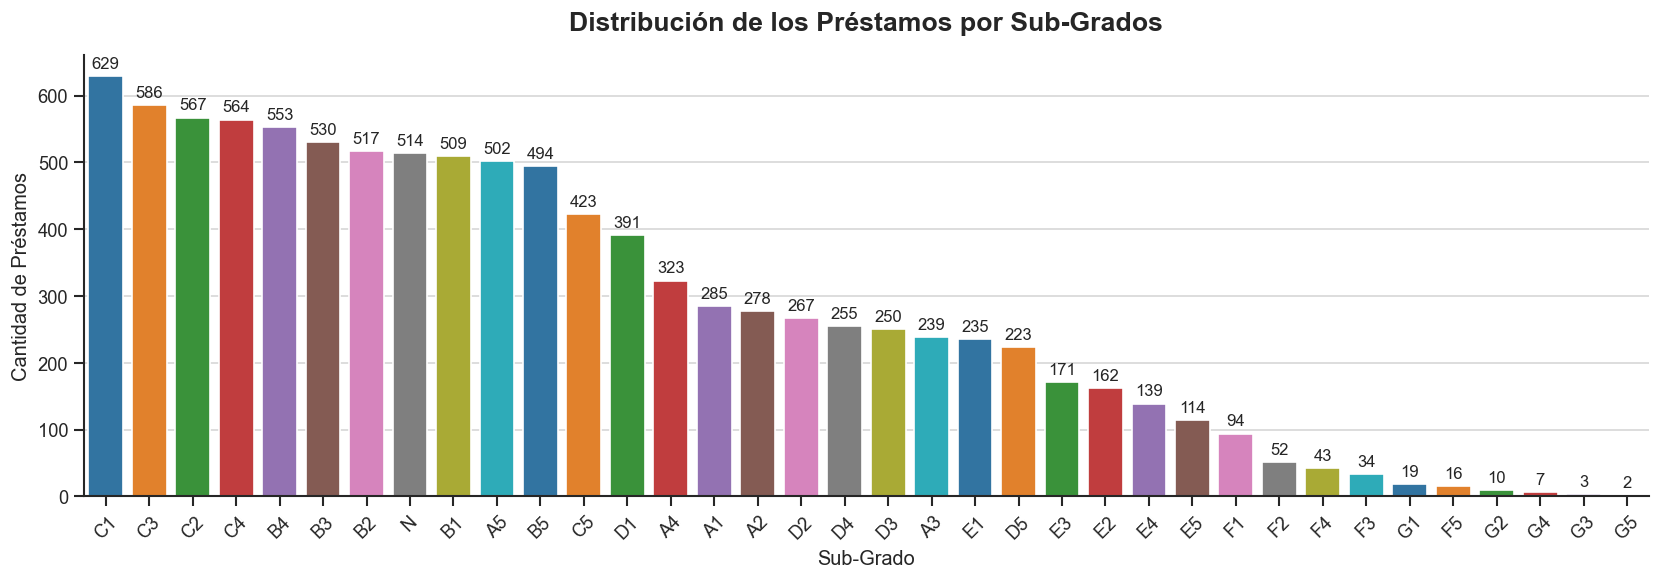

In [1773]:
plot_grafico_barra(
    data_pandas=pandas_subgrado,
    cols=['data', 'count'],
    titulo='Distribución de los Préstamos por Sub-Grados',
    xlabel='Sub-Grado',
    ylabel='Cantidad de Préstamos',
    ancho=14
)

La distribución de préstamos por sub-grado muestra una marcada concentración de registros en las categorías asociadas a los grados B y C, particularmente en los sub-grados C1, C2, C3, C4, B1, B2, B3 y B4. 

En contraste, los sub-grados pertenecientes a las categorías E, F y G presentan una frecuencia considerablemente menor, evidenciando una disminución progresiva en la cantidad de préstamos conforme aumenta el nivel de riesgo crediticio.

Asimismo, se identifica una cantidad significativa de registros clasificados dentro de la categoría N, correspondiente a préstamos sin una clasificación de sub-grado definida. Debido a su elevada frecuencia, resulta conveniente analizar estos registros con mayor detalle y evaluar la posibilidad de recuperar la información faltante mediante procesos de imputación.

En términos generales, la distribución observada sugiere que la cartera de préstamos se encuentra concentrada en clientes con perfiles de riesgo intermedio, mientras que los préstamos asociados a niveles de riesgo elevados constituyen una proporción reducida del conjunto de datos.

#### *Cuantificación de los Valores Ausentes por Categorías*

In [1774]:
np.sum(temporal_grado[0] == 'N')

np.int64(515)

Existen 515 elementos dentro de la variable `grado` que tiene asignado el valor ''

In [1775]:
np.sum(temporal_grado[1] == 'N')

np.int64(514)

Existen 514 elementos dentro de la variable `sub_grado` que tiene asignado el valor ''

In [1776]:
np.sum((temporal_grado[0] == 'N') & (temporal_grado[1] == 'N'))

np.int64(9)

Se identifican 9 registros para los cuales tanto la variable `grade` como la variable `sub_grade` presentan la etiqueta vacía (''). Esta situación indica la ausencia simultánea de información en ambas variables, lo que imposibilita la aplicación de estrategias de imputación basadas en la correspondencia existente entre sus categorías.

Por lo tanto, estos registros deberán analizarse de manera particular para determinar si es posible recuperar la información a partir de otras variables relacionadas o si resulta necesario aplicar un tratamiento alternativo durante la etapa de limpieza de datos.

#### *Proceso de Imputación Cruzada (Grado)*

La primera etapa del proceso de imputación consiste en asignar a la variable grade aquellos valores no especificados a partir de la clasificación registrada en la variable sub_grade. Dado que el grado principal se encuentra representado por la primera letra del sub-grado correspondiente, es posible recuperar esta información de manera directa cuando sub_grade contiene una clasificación válida.

En los casos en que tanto grade como sub_grade presentan un valor no especificado, se conserva dicha codificación debido a que no existe información suficiente para inferir la categoría correspondiente.

In [1777]:
temporal_grado[0] = np.array([
    temporal_grado[1][i][0] if ((temporal_grado[0][i] == 'N') and (temporal_grado[1][i] != 'N'))
    else temporal_grado[0][i]
    for i in range(len(temporal_grado[1]))
])

In [1778]:
pd.DataFrame(np.array(temporal_grado).transpose(), columns=['grado', 'sub_grado']).head(10)

,grado,sub_grado
0,C,C3
1,A,A5
2,B,B5
3,A,A5
4,E,E3
5,C,C4
6,F,F4
7,C,C3
8,A,A5
9,C,C2


#### *Proceso de Imputación Completa (Grado)*

En este caso, los valores faltantes se imputan mediante la introducción de una nueva categoría, denominada `H`, la cual representa una clasificación con una penalización más severa que las categorías definidas explícitamente.

In [1779]:
temporal_grado[0] = np.where(
    temporal_grado[0] == 'N',
    'H',
    temporal_grado[0]
)

In [1780]:
pd.DataFrame(np.array(temporal_grado).transpose(), columns=['grado', 'sub_grado']).head(10)

,grado,sub_grado
0,C,C3
1,A,A5
2,B,B5
3,A,A5
4,E,E3
5,C,C4
6,F,F4
7,C,C3
8,A,A5
9,C,C2


#### Visualización del proceso de imputación

In [1781]:
pandas_grado = pd.Series(temporal_grado[-2]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_grado['porcentaje'] = pandas_grado['count']/len(temporal_grado[-2])*100
pandas_grado

,data,count,porcentaje
0,C,2923,29.23
1,B,2742,27.42
2,A,1717,17.17
3,D,1451,14.51
4,E,867,8.67
5,F,247,2.47
6,G,44,0.44
7,H,9,0.09


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


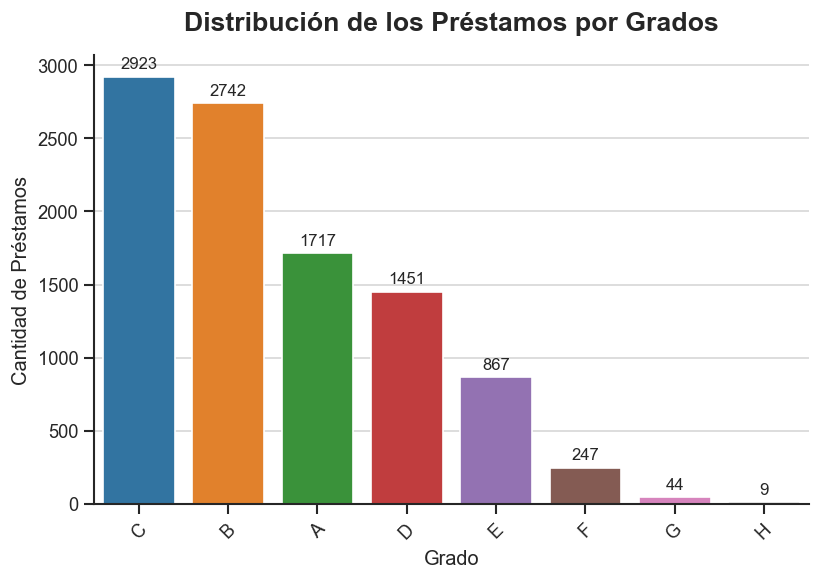

In [1782]:
plot_grafico_barra(
    data_pandas=pandas_grado,
    cols=['data', 'count'],
    titulo='Distribución de los Préstamos por Grados',
    xlabel='Grado',
    ylabel='Cantidad de Préstamos'
)

Con el proceso de imputación desarrollado, se logra corregir de manera efectiva la presencia de registros no definidos explícitamente, asegurando que los valores imputados fueron asignados correctamente mediante un método de validación cruzada. Asimismo, se observa que la nueva distribución no presenta cambios relevantes respecto a la distribución original.

#### *Proceso de Imputación Completa (Sub-Grado)*

En la primera etapa del proceso de imputación, los valores faltantes de los registros de la variable de sub-grados se recodifican como 'H1', una categoría adicional incorporada con el objetivo de representar una condición menos favorable del préstamo otorgado.

In [1783]:
temporal_grado[1] = np.where(
    temporal_grado[1] == 'N',
    'H1',
    temporal_grado[1]
)

In [1784]:
pd.DataFrame(np.array(temporal_grado).transpose(), columns=['grado', 'sub_grado']).head(10)

,grado,sub_grado
0,C,C3
1,A,A5
2,B,B5
3,A,A5
4,E,E3
5,C,C4
6,F,F4
7,C,C3
8,A,A5
9,C,C2


#### *Proceso de Imputación Cruzada (Sub-Grado)*

Se corrigen los valores imputados de forma absoluta en la etapa anterior mediante una imputación cruzada que considera la información contenida en la variable `grade`. Este ajuste permite evitar la sobrepenalización de los valores faltantes inicialmente en la variable `sub_grade`. Para ello, se establece una correspondencia entre las categorías alfabéticas definidas en `grade` y su representación numérica. En los casos en que no es posible determinar dicha correspondencia, se asigna la penalización máxima en la codificación numérica, equivalente a un valor de 5.

In [1785]:
temporal_grado[1] = np.where(
    ((temporal_grado[1] == 'H1') & (temporal_grado[0] != 'H')),
    (temporal_grado[0] + '5'),
    temporal_grado[1]
)

#### *Codificación numerada de los valores contenidos en la variable grado*

In [1786]:
dict_grado = {}
j = 0
for i in list(np.unique(temporal_grado[0])):
    dict_grado[i] = j
    j += 1
codificacion_grado = np.array([dict_grado[i] for i in temporal_grado[0]])
temporal_grado.append(codificacion_grado)
temporal_grado

[array(['C', 'A', 'B', ..., 'A', 'D', 'A'], shape=(10000,), dtype='<U1'),
 array(['C3', 'A5', 'B5', ..., 'A5', 'D2', 'A4'], shape=(10000,), dtype='<U69'),
 array([2, 0, 1, ..., 0, 3, 0], shape=(10000,))]

#### *Codificación numerada de los valores contenidos en la variable sub_grado*

In [1787]:
dict_grado = {}
j = 0
for i in list(np.unique(temporal_grado[1])):
    dict_grado[i] = j
    j += 1
codificacion_grado = np.array([dict_grado[i] for i in temporal_grado[1]])
temporal_grado.append(codificacion_grado)
temporal_grado

[array(['C', 'A', 'B', ..., 'A', 'D', 'A'], shape=(10000,), dtype='<U1'),
 array(['C3', 'A5', 'B5', ..., 'A5', 'D2', 'A4'], shape=(10000,), dtype='<U69'),
 array([2, 0, 1, ..., 0, 3, 0], shape=(10000,)),
 array([12,  4,  9, ...,  4, 16,  3], shape=(10000,))]

#### *Empaquetado de los valores imputados condificados dentro del arreglo de variables categóricas*

In [1788]:
etiquetas_grado = ['grado', 'sub_grado', 'grado_codificado', 'sub_grado_codificado']
for i in range(len(temporal_grado)):
    data_categoricos_codificados.append(temporal_grado[i])
    etiquetas_categoricos_codificados.append(etiquetas_grado[i])
    if i > 1:
        columnas_numericas.append(etiquetas_categoricos_codificados[-1])

In [1789]:
print(etiquetas_categoricos_codificados)
print(data_categoricos_codificados)

['identificador', 'fecha_prestamo', 'estado_prestamo', 'riesgo_prestamo', 'clasificacion_estado_prestamo', 'duracion_prestamo_meses', 'duracion_prestamo_meses_imputados', 'grado', 'sub_grado', 'grado_codificado', 'sub_grado_codificado']
[array(['48010226', '57693261', '59432726', ..., '50415990', '46154151', '66055249'],
      shape=(10000,), dtype='<U69'), array([ 5,  0,  9, ...,  6,  4, 12], shape=(10000,)), array(['Current', 'Current', 'Current', ..., 'Current', 'Current', 'Current'],
      shape=(10000,), dtype='<U18'), array(['Bajo', 'Bajo', 'Bajo', ..., 'Bajo', 'Bajo', 'Bajo'], shape=(10000,), dtype='<U15'), array(['Positivo', 'Positivo', 'Positivo', ..., 'Positivo', 'Positivo', 'Positivo'],
      shape=(10000,), dtype='<U8'), array([36., 36., 36., ..., 36., 36., 36.], shape=(10000,)), array([36., 36., 36., ..., 36., 36., 36.], shape=(10000,)), array(['C', 'A', 'B', ..., 'A', 'D', 'A'], shape=(10000,), dtype='<U1'), array(['C3', 'A5', 'B5', ..., 'A5', 'D2', 'A4'], shape=(10000,),

In [1790]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(10)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,sub_grado_codificado
0,48010226,5,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12
1,57693261,0,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4
2,59432726,9,Current,Bajo,Positivo,36.0,36.0,B,B5,1,9
3,53222800,7,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4
4,57803010,8,Current,Bajo,Positivo,36.0,36.0,E,E3,4,22
5,63398019,10,Current,Bajo,Positivo,60.0,60.0,C,C4,2,13
6,60850626,9,Current,Bajo,Positivo,60.0,60.0,F,F4,5,28
7,46816139,4,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12
8,63918356,11,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4
9,63651616,11,Current,Bajo,Positivo,36.0,36.0,C,C2,2,11


### **Categoría: verification_status**

In [1791]:
valor = 6

#### *Análisis de datos faltantes*

In [1792]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `varification_status`, lo que indica que todos los elementos de esta columna contienen información válida y completa dentro del conjunto de datos analizado.

Esta verificación sugiere que la variable no presenta datos faltantes, por lo que no requiere la aplicación de técnicas de imputación en etapas posteriores del preprocesamiento.

#### *Exploración general de los datos*

In [1793]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la segunda columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'Not Verified' 'Source Verified' 'Verified']
verification_status


Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.

#### *Cantidad de valores únicos*

In [1794]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'issue_d'

4


El análisis de esta variable revela la existencia de* **4** *categorías diferentes.

- De estas categorías*, **3** *se corresponden al estado de verificación de la información del cliente asociada a sus niveles de ingresos. 

- Por otra parte, la categoría restante agrupa aquellos registros para los cuales no se dispone de información relativa a este acápite.

#### *Proceso de Recategorización*

Recategorización del estado de verificación no definido de manera explícita de manera tal que se define con la etiqueta 'No especificado'.

In [1795]:
data_categoricos_codificados.append(np.array(
    [data_categoricos[valor][i] if data_categoricos[valor][i] != '' else 'No especificado' 
    for i in range(len(data_categoricos[valor]))
    ])
)
etiquetas_categoricos_codificados.append('estado_verificacion')

#### *Estructura de los Datos Modificados*

In [1796]:
pandas_verificacion = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_verificacion['porcentaje'] = pandas_verificacion['count']/len(data_categoricos_codificados[-1])*100
pandas_verificacion

,data,count,porcentaje
0,Source Verified,4116,41.16
1,Verified,2711,27.11
2,Not Verified,2673,26.73
3,No especificado,500,5.00


#### *Graficado de la Distribución de los Valores de la Categoría*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


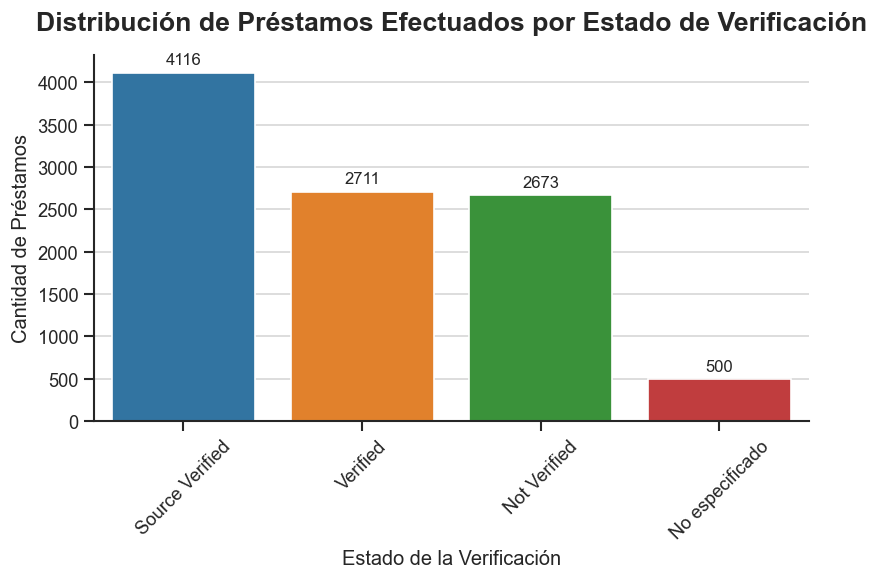

In [1797]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Estado de Verificación',
    data_pandas=pandas_verificacion,
    cols=['data', 'count'],
    xlabel='Estado de la Verificación',
    ylabel='Cantidad de Préstamos'
)

La distribución de préstamos según el estado de verificación muestra que la categoría "Source Verified" concentra la mayor cantidad de registros, con **4,116** préstamos, representando aproximadamente el **41.1 %** del total. Esto indica que una proporción importante de los solicitantes proporcionó información cuya fuente fue validada por la entidad financiera.

Las categorías "Verified" y "Not Verified" presentan cantidades similares, con **2,711** y **2,673** préstamos, respectivamente, equivalentes al **27.1 %** y **26.7 %** del total. Esta distribución relativamente equilibrada permitirá realizar comparaciones posteriores entre clientes con información verificada y no verificada sin que exista un desbalance significativo entre ambos grupos.

Por otra parte, la categoría "No especificado" registra únicamente **500** préstamos (**5.0 %** del total), por lo que su impacto sobre la distribución general es reducido. Sin embargo, será conveniente evaluar si estos registros deben conservarse, imputarse o excluirse dependiendo de los objetivos del análisis.

En términos generales, se observa que cerca del **68 %** de los préstamos corresponden a registros con algún tipo de verificación (Verified o Source Verified), lo que sugiere una alta proporción de clientes cuya información fue sometida a procesos de validación. Este comportamiento podría ser relevante al estudiar variables relacionadas con el riesgo crediticio, la aprobación de préstamos o las tasas de incumplimiento.

#### *Proceso de Imputación*

El proceso de imputación se realizó bajo un criterio conservador, de modo que aquellos préstamos cuyo estado de verificación no fue especificado explícitamente fueron clasificados como "Not Verified". Esta decisión permite considerar el escenario menos favorable para las instituciones financieras, asumiendo que la información asociada al solicitante no fue sometida a ningún proceso de validación. De esta manera, el análisis se desarrolla bajo una condición de mayor riesgo, proporcionando resultados más robustos desde la perspectiva de la evaluación crediticia.

In [1798]:
data_categoricos_codificados.append(np.array(
    [data_categoricos_codificados[-1][i] if data_categoricos_codificados[-1][i] != 'No especificado' else 'Not Verified' 
    for i in range(len(data_categoricos_codificados[-1]))
    ])
)
etiquetas_categoricos_codificados.append('estado_verificacion_imputado')

#### *Verificación de la Imputación*

In [1799]:
pandas_verificacion_imputados = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_verificacion_imputados['porcentaje'] = pandas_verificacion_imputados['count']/len(data_categoricos_codificados[-1])*100
pandas_verificacion_imputados

,data,count,porcentaje
0,Source Verified,4116,41.16
1,Not Verified,3173,31.73
2,Verified,2711,27.11


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


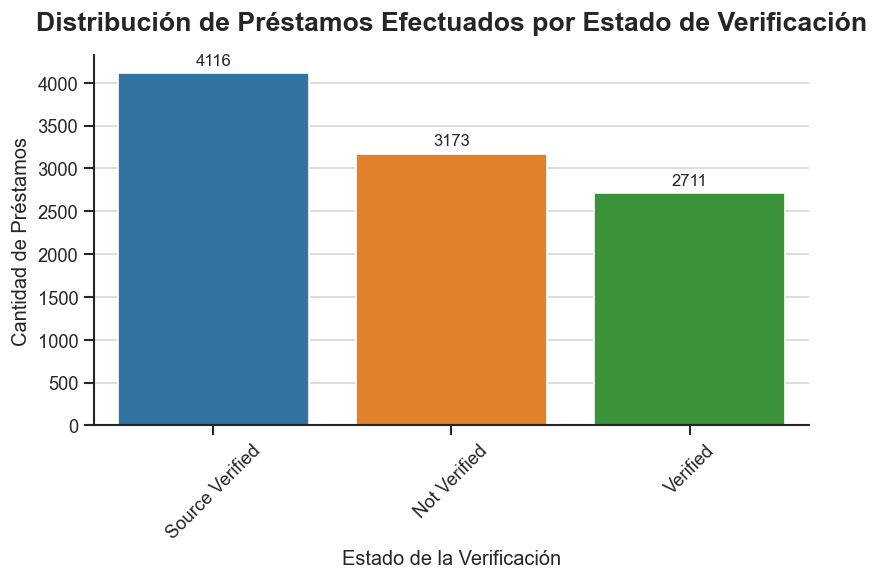

In [1800]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Estado de Verificación',
    data_pandas=pandas_verificacion_imputados,
    cols=['data', 'count'],
    xlabel='Estado de la Verificación',
    ylabel='Cantidad de Préstamos'
)

Después de la imputación, la distribución final muestra que "Source Verified" continúa siendo la categoría predominante con **4,116** préstamos, seguida de "Not Verified" con **3,173** registros y "Verified" con **2,711** registros. La eliminación de la categoría de valores no especificados permite disponer de una variable completamente definida para los análisis posteriores, manteniendo además una perspectiva conservadora en la evaluación del riesgo asociado a los préstamos.

Como resultado, se obtiene un conjunto de datos libre de valores faltantes en esta variable, preservando la consistencia de la información y garantizando que los análisis posteriores se realicen bajo un escenario que no subestima el riesgo potencial para las instituciones financieras.

#### *Conversión de datos a binarios*

Con el objetivo de simplificar el análisis y reducir el efecto del desbalance existente entre las categorías individuales, se plantea una recodificación binaria del estado de verificación, agrupando las categorías originales de la siguiente manera:

- *Estado positivo* (valor -> 1): Source Verified y Verified.

- *Estado negativo* (valor -> 0): Not Verified.

Esta transformación permite distinguir entre préstamos asociados a solicitantes cuya información fue sometida a algún proceso de validación y aquellos para los cuales no existe evidencia de verificación. Asimismo, la agrupación reduce la fragmentación de la variable original y facilita la interpretación de los resultados obtenidos en etapas posteriores del análisis.

Adicionalmente, esta recodificación contribuye a mitigar posibles sesgos derivados de la representación desigual de las categorías originales, permitiendo realizar comparaciones más consistentes entre registros verificados y no verificados, especialmente en estudios relacionados con el riesgo crediticio, el incumplimiento de pagos o la aprobación de préstamos.

In [1801]:
data_categoricos_codificados.append(np.array(
    ['Negativo' if data_categoricos_codificados[-1][i] == 'Not Verified' else 'Positivo' 
    for i in range(len(data_categoricos_codificados[-1]))
    ])
)
etiquetas_categoricos_codificados.append('estado_verificacion_binario')

#### *Estructura de los Datos Modificados*

In [1802]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(10)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,sub_grado_codificado,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario
0,48010226,5,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12,Verified,Verified,Positivo
1,57693261,0,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo
2,59432726,9,Current,Bajo,Positivo,36.0,36.0,B,B5,1,9,Verified,Verified,Positivo
3,53222800,7,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Not Verified,Not Verified,Negativo
4,57803010,8,Current,Bajo,Positivo,36.0,36.0,E,E3,4,22,Source Verified,Source Verified,Positivo
5,63398019,10,Current,Bajo,Positivo,60.0,60.0,C,C4,2,13,Not Verified,Not Verified,Negativo
6,60850626,9,Current,Bajo,Positivo,60.0,60.0,F,F4,5,28,Source Verified,Source Verified,Positivo
7,46816139,4,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12,No especificado,Not Verified,Negativo
8,63918356,11,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo
9,63651616,11,Current,Bajo,Positivo,36.0,36.0,C,C2,2,11,No especificado,Not Verified,Negativo


### **Categoría: url**

In [1803]:
valor = 7

#### *Análisis de datos faltantes*

No se identifican valores nulos en los registros correspondientes a la variable `url`, lo que indica que todos los elementos de esta columna contienen información válida y completa dentro del conjunto de datos analizado.

Esta verificación sugiere que la variable no presenta datos faltantes, por lo que no requiere la aplicación de técnicas de imputación en etapas posteriores del preprocesamiento.

In [1804]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

In [1805]:
print(f'Cantidad de valores únicos: {len(np.unique(data_categoricos[valor]))}')
print(f'Cantidad total de valores: {len(data_categoricos[valor])}')

Cantidad de valores únicos: 10000
Cantidad total de valores: 10000


No se considera la inclusión de esta categoría dentro del conjunto de variables categóricas procesadas, ya que no aporta información relevante para el análisis. Cada URL es única para cada préstamo registrado y procesado, por lo que su comportamiento es análogo al de una variable identificadora. En consecuencia, su incorporación no contribuye a la generación de patrones ni a la capacidad predictiva del modelo.

### **Categoría: addr_state**

In [1806]:
valor = 8

#### *Análisis de datos faltantes*

In [1807]:
pd.isna(data_categoricos[valor]).sum()

np.int64(0)

No se identifican valores nulos en los registros correspondientes a la variable `url`, lo que indica que todos los elementos de esta columna contienen información válida y completa dentro del conjunto de datos analizado.

Esta verificación sugiere que la variable no presenta datos faltantes, por lo que no requiere la aplicación de técnicas de imputación en etapas posteriores del preprocesamiento.

#### *Exploración general de los datos*

In [1808]:
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la segunda columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'AK' 'AL' 'AR' 'AZ' 'CA' 'CO' 'CT' 'DC' 'DE' 'FL' 'GA' 'HI' 'IL' 'IN' 'KS' 'KY' 'LA' 'MA' 'MD'
 'ME' 'MI' 'MN' 'MO' 'MS' 'MT' 'NC' 'ND' 'NE' 'NH' 'NJ' 'NM' 'NV' 'NY' 'OH' 'OK' 'OR' 'PA' 'RI'
 'SC' 'SD' 'TN' 'TX' 'UT' 'VA' 'VT' 'WA' 'WI' 'WV' 'WY']
addr_state


Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas. Los valores contenidos en esta variable se corresponde a los acrónicos utilizados para denotar estados de los Estados Unidos.

#### *Cantidad de valores únicos*

In [1809]:
print(len(np.unique(data_categoricos[valor])))  

50


Se identificaron 50 valores distintos dentro de las especificaciones de esta variable, los cuales pueden asociarse a las abreviaturas correspondientes a los 50 estados de los Estados Unidos. Sin embargo, también se observa la presencia de una etiqueta vacía (''), cuya existencia puede atribuirse a dos posibles situaciones:

- La ausencia de una de las abreviaturas utilizadas para representar alguno de los estados de los Estados Unidos.

- La existencia de uno o más registros para los cuales el estado de origen no fue especificado explícitamente.

Debido a que no es posible determinar de manera inequívoca cuál de estas situaciones ocurre únicamente a partir de la información disponible, se decide recodificar la etiqueta vacía mediante el acrónimo ENE (Estado No Especificado). Esta nueva categoría permite conservar los registros asociados, evitando la pérdida de información y diferenciando explícitamente los casos en los que el estado de origen no puede ser identificado dentro del conjunto de datos.

#### *Proceso de Recategorización*

In [1810]:
data_categoricos_codificados.append(np.array(
    [data_categoricos[valor][i] if data_categoricos[valor][i] != '' else 'ENE' 
    for i in range(len(data_categoricos[valor]))
    ])
)
etiquetas_categoricos_codificados.append('estado_direccion')

#### *Estructura de los Datos Modificados*

In [1811]:
pandas_estado_direccion = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_estado_direccion['porcentaje'] = pandas_estado_direccion['count']/len(data_categoricos_codificados[-1])*100
pandas_estado_direccion

,data,count,porcentaje
0,CA,1336,13.36
1,NY,777,7.77
2,TX,758,7.58
3,FL,690,6.90
4,ENE,500,5.00
5,IL,389,3.89
6,NJ,341,3.41
7,GA,321,3.21
8,PA,320,3.20
9,OH,312,3.12


#### *Graficado de los Datos*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


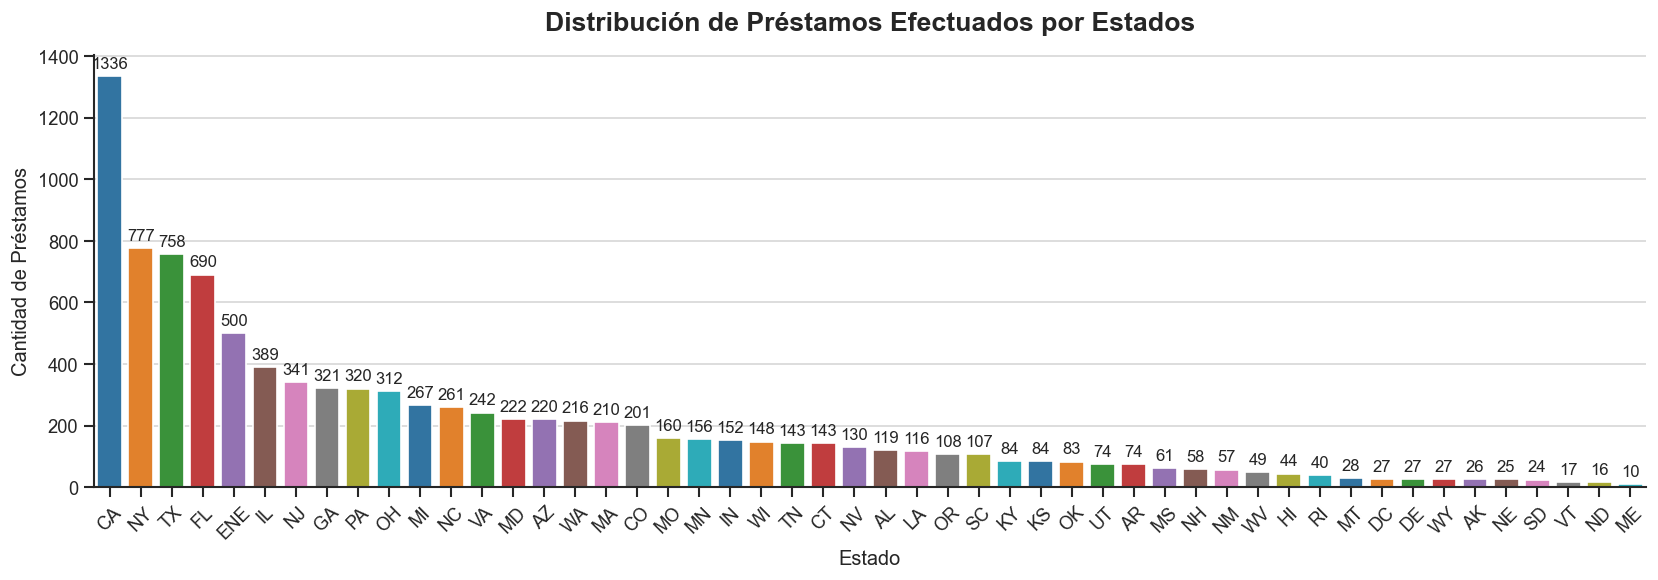

In [1812]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Estados',
    data_pandas=pandas_estado_direccion,
    cols=['data', 'count'],
    xlabel='Estado',
    ylabel='Cantidad de Préstamos',
    ancho=14
)

La distribución de préstamos por estado muestra una marcada concentración geográfica. El estado de California (CA) registra la mayor cantidad de préstamos, con 1,336 operaciones, superando ampliamente al resto de los estados analizados. En un segundo grupo se encuentran Nueva York (NY) con 777 préstamos, Texas (TX) con 758 y Florida (FL) con 690, que también presentan una participación considerable dentro de la cartera total.

Adicionalmente, la categoría ENE (Estado No Especificado) concentra 500 registros, ubicándose entre los estados con mayor frecuencia. Esto indica que una proporción relevante de los préstamos no cuenta con información geográfica explícita, situación que deberá considerarse en análisis posteriores donde la localización del solicitante sea una variable de interés.

A partir de los estados con mayor participación, se observa una disminución progresiva en la cantidad de préstamos registrados. La mayoría de los estados presentan menos de 350 operaciones, mientras que varios registran menos de 100 préstamos, evidenciando una distribución heterogénea y fuertemente sesgada hacia un grupo reducido de estados.

Este comportamiento sugiere que la actividad crediticia de la muestra se encuentra concentrada principalmente en estados con alta población y elevada actividad económica, como California, Nueva York, Texas y Florida. Por lo tanto, cualquier análisis relacionado con el comportamiento crediticio, la morosidad o el riesgo financiero podría verse influenciado por las características particulares de estas regiones, debido a su elevada representación dentro del conjunto de datos.

La distribución presenta características de una distribución de tipo cola larga (long-tail), donde un pequeño número de estados concentra una proporción significativa de los préstamos, mientras que una gran cantidad de estados posee una representación relativamente reducida. Este comportamiento debe considerarse al realizar análisis comparativos entre estados, ya que los tamaños de muestra disponibles no son homogéneos y podrían afectar la robustez de las conclusiones obtenidas para los estados con menor número de registros.

#### *Recategorización de los valores según región*

La recategorización de esta variable se realizará agrupando los estados de acuerdo con la región geográfica a la que pertenecen dentro de los Estados Unidos. Mediante esta estrategia, los estados serán segmentados en cuatro regiones principales, permitiendo reducir la granularidad de la variable original y obtener grupos con una mayor cantidad de observaciones. Las regiones utilizadas para realizar la recategorización son las siguientes:

- west

- south

- midwest

- east

Asimismo, esta transformación contribuye a mitigar el impacto de los registros asociados a estados no especificados, ya que la reducción en el número de categorías disminuye el efecto que los valores faltantes pueden ejercer sobre los análisis posteriores. Como resultado, se obtiene una representación geográfica más compacta y robusta, facilitando la identificación de patrones regionales y mejorando la estabilidad de los análisis estadísticos y predictivos.

En el caso de los estados no especificados se le asignará la etiqueta 'RNE', la cual significaría región no especificada.

In [1813]:
dict_regiones = {
    'west' : ['WA', 'OR','CA','NV','ID','MT', 'WY','UT','CO', 'AZ','NM','HI','AK'],
    'south' : ['TX','OK','AR','LA','MS','AL','TN','KY','FL','GA','SC','NC','VA','WV','MD','DE','DC'],
    'midwest' : ['ND','SD','NE','KS','MN','IA','MO','WI','IL','IN','MI','OH'],
    'east' : ['PA','NY','NJ','CT','MA','VT','NH','ME','RI']
}
keys_regiones = dict_regiones.keys()

temporal_regiones = []
for i in data_categoricos_codificados[-1]:
    if i == 'ENE':
        temporal_regiones.append('RNE')
    else:
        for j in keys_regiones:
            if i in dict_regiones[j]:
                temporal_regiones.append(j)

In [1814]:
data_categoricos_codificados.append(np.array(temporal_regiones))
etiquetas_categoricos_codificados.append('regiones_direccion')

#### *Estructura de los Datos Modificados*

In [1815]:
pandas_region_direccion = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_region_direccion['porcentaje'] = pandas_region_direccion['count']/len(data_categoricos_codificados[-1])*100
pandas_region_direccion

,data,count,porcentaje
0,south,3384,33.84
1,west,2467,24.67
2,east,1916,19.16
3,midwest,1733,17.33
4,RNE,500,5.00


#### *Graficado de la Recategorización de los Estados por Regiones*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_21344\1975212048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


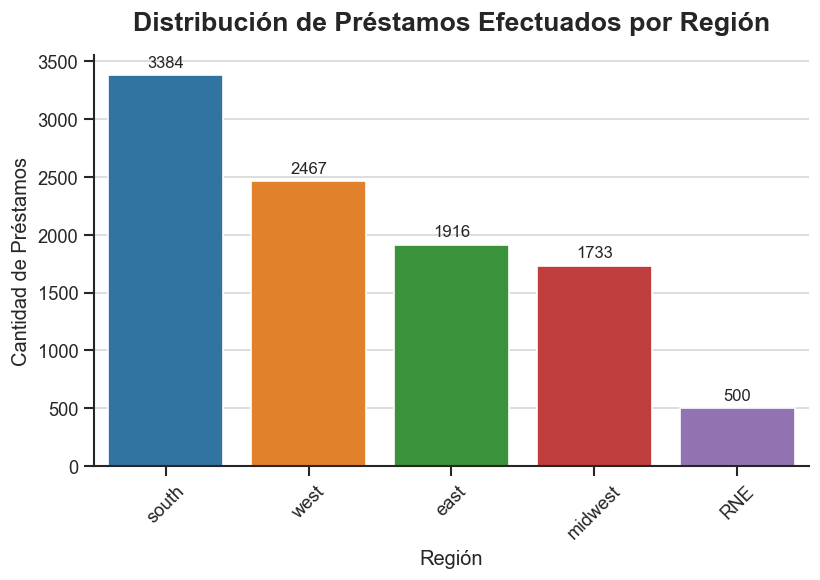

In [1816]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Región',
    data_pandas=pandas_region_direccion,
    cols=['data', 'count'],
    xlabel='Región',
    ylabel='Cantidad de Préstamos',
    ancho=7
)

Se observa que el proceso de recategorización cumple adecuadamente con el objetivo planteado, ya que permitió reducir el efecto adverso de los registros con estados no especificados en la variable correspondiente. De esta manera, se obtiene una representación más consistente de la información, lo que favorece un análisis más preciso de las regiones en las que se encuentran ubicadas las instituciones financieras cuyos préstamos fueron registrados en la base de datos.

#### *Visualización de la Base de Datos*

In [1817]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(10)

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,sub_grado_codificado,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario,estado_direccion,regiones_direccion
0,48010226,5,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12,Verified,Verified,Positivo,CA,west
1,57693261,0,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo,NY,east
2,59432726,9,Current,Bajo,Positivo,36.0,36.0,B,B5,1,9,Verified,Verified,Positivo,PA,east
3,53222800,7,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Not Verified,Not Verified,Negativo,OH,midwest
4,57803010,8,Current,Bajo,Positivo,36.0,36.0,E,E3,4,22,Source Verified,Source Verified,Positivo,TX,south
5,63398019,10,Current,Bajo,Positivo,60.0,60.0,C,C4,2,13,Not Verified,Not Verified,Negativo,AL,south
6,60850626,9,Current,Bajo,Positivo,60.0,60.0,F,F4,5,28,Source Verified,Source Verified,Positivo,CA,west
7,46816139,4,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12,No especificado,Not Verified,Negativo,GA,south
8,63918356,11,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo,MA,east
9,63651616,11,Current,Bajo,Positivo,36.0,36.0,C,C2,2,11,No especificado,Not Verified,Negativo,TX,south


### **Conformación del DataFrame asociados a las variables categóricas**

In [1818]:
pandas_categorico = pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados)
pandas_categorico.tail()

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,sub_grado_codificado,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario,estado_direccion,regiones_direccion
9995,42974433,3,Current,Bajo,Positivo,36.0,36.0,B,B1,1,5,Source Verified,Source Verified,Positivo,WY,west
9996,45424654,4,Current,Bajo,Positivo,36.0,36.0,B,B3,1,7,No especificado,Not Verified,Negativo,OR,west
9997,50415990,6,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo,CA,west
9998,46154151,4,Current,Bajo,Positivo,36.0,36.0,D,D2,3,16,Source Verified,Source Verified,Positivo,OH,midwest
9999,66055249,12,Current,Bajo,Positivo,36.0,36.0,A,A4,0,3,No especificado,Not Verified,Negativo,IL,midwest


#### **Casteo del formato de las variables numéricas en el DataFrame**

In [1819]:
pandas_categorico[columnas_numericas] = pandas_categorico[columnas_numericas].apply(pd.to_numeric, errors='coerce')

## Procesamiento de datos numéricos

En esta sección se describe el proceso de análisis y preprocesamiento de los datos numéricos contenidos en la base de datos proporcionada. El objetivo de esta etapa es garantizar la calidad, consistencia e integridad de la información antes de su utilización en fases posteriores del análisis.

El procedimiento contempla la identificación de valores faltantes y su estandarización mediante la asignación de un formato adecuado que permita su correcto procesamiento. La imputación de dichos valores se realizará una vez que la base de datos se encuentre completamente integrada.

### **Cantidad de datos numéricos**

In [1820]:
print(len(etiqueta_numericos))
print(etiqueta_numericos)
data_numericos_codificados, etiquetas_numericos_codificados = [], []        # Inicialización de arreglos vacíos para almacenar los datos y las etiquetas asociados a variables categóricas y binarias procesadas.
print(data_numericos[:,:5])

6
[np.str_('id'), np.str_('loan_amnt'), np.str_('funded_amnt'), np.str_('int_rate'), np.str_('installment'), np.str_('total_pymnt')]
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['9452.96' '4679.7' '1969.83' '1793.68' '1178.51']]


### **Categoría: id**

In [1821]:
valor = 0

No es necesario realizar ningún análisis adicional sobre estas variables, ya que los resultados obtenidos previamente respaldan esta decisión, al no haberse identificado valores duplicados ni valores nulos.

In [1822]:
data_numericos_codificados.append(np.array(data_numericos[valor]))
etiquetas_numericos_codificados.append('identificador')

In [1823]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador
0,48010226
1,57693261
2,59432726
3,53222800
4,57803010
...,...
9995,42974433
9996,45424654
9997,50415990
9998,46154151


### **Categoría: loan_amnt**

In [1824]:
valor = 1

#### *Análisis de datos faltantes*

In [1825]:
pd.isna(data_numericos[valor]).sum()

np.int64(0)

Se observa que no existen datos registrados como explícitamente faltantes.

#### *Casteo de los datos*

In [1826]:
temporal = []
for i in data_numericos[valor]:
    try:
        x = float(i)
    except:
        x = np.nan
    finally:
        temporal.append(x)
data_numericos_codificados.append(np.array(temporal))
etiquetas_numericos_codificados.append('prestamo_solicitado')

#### *Visualización del DataFrame*

In [1827]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador,prestamo_solicitado
0,48010226,35000.0
1,57693261,30000.0
2,59432726,15000.0
3,53222800,9600.0
4,57803010,8075.0
...,...,...
9995,42974433,18000.0
9996,45424654,11300.0
9997,50415990,10000.0
9998,46154151,nan


### **Categoría: funded_amnt**

In [1828]:
valor = 2

#### *Análisis de datos faltantes*

In [1829]:
pd.isna(data_numericos[valor]).sum()

np.int64(0)

Se observa que no existen datos registrados como explícitamente faltantes.

#### *Casteo de los datos*

In [1830]:
temporal = []
for i in data_numericos[valor]:
    try:
        x = float(i)
    except:
        x = np.nan
    finally:
        temporal.append(x)
data_numericos_codificados.append(np.array(temporal))
etiquetas_numericos_codificados.append('prestamo_aceptado')

#### *Visualización del DataFrame*

In [1831]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador,prestamo_solicitado,prestamo_aceptado
0,48010226,35000.0,35000.0
1,57693261,30000.0,30000.0
2,59432726,15000.0,15000.0
3,53222800,9600.0,9600.0
4,57803010,8075.0,8075.0
...,...,...,...
9995,42974433,18000.0,18000.0
9996,45424654,11300.0,11300.0
9997,50415990,10000.0,10000.0
9998,46154151,nan,10000.0


### **Categoría: int_rate**

In [1832]:
valor = 3

#### *Análisis de datos faltantes*

In [1833]:
pd.isna(data_numericos[valor]).sum()

np.int64(0)

Se observa que no existen datos registrados como explícitamente faltantes.

#### *Casteo de los datos*

In [1834]:
temporal = []
for i in data_numericos[valor]:
    try:
        x = float(i)
    except:
        x = np.nan
    finally:
        temporal.append(x)
data_numericos_codificados.append(np.array(temporal))
etiquetas_numericos_codificados.append('interes_prestamo')

#### *Visualización del DataFrame*

In [1835]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador,prestamo_solicitado,prestamo_aceptado,interes_prestamo
0,48010226,35000.0,35000.0,13.33
1,57693261,30000.0,30000.0,nan
2,59432726,15000.0,15000.0,nan
3,53222800,9600.0,9600.0,nan
4,57803010,8075.0,8075.0,19.19
...,...,...,...,...
9995,42974433,18000.0,18000.0,nan
9996,45424654,11300.0,11300.0,nan
9997,50415990,10000.0,10000.0,nan
9998,46154151,nan,10000.0,16.55


### **Categoría: installment**

In [1836]:
valor = 4

#### *Análisis de datos faltantes*

In [1837]:
pd.isna(data_numericos[valor]).sum()

np.int64(0)

Se observa que no existen datos registrados como explícitamente faltantes.

#### *Casteo de los datos*

In [1838]:
temporal = []
for i in data_numericos[valor]:
    try:
        x = float(i)
    except:
        x = np.nan
    finally:
        temporal.append(x)
data_numericos_codificados.append(np.array(temporal))
etiquetas_numericos_codificados.append('pago_mensual')

#### *Visualización del DataFrame*

In [1839]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador,prestamo_solicitado,prestamo_aceptado,interes_prestamo,pago_mensual
0,48010226,35000.0,35000.0,13.33,1184.86
1,57693261,30000.0,30000.0,nan,938.57
2,59432726,15000.0,15000.0,nan,494.86
3,53222800,9600.0,9600.0,nan,300.35
4,57803010,8075.0,8075.0,19.19,296.78
...,...,...,...,...,...
9995,42974433,18000.0,18000.0,nan,565.56
9996,45424654,11300.0,11300.0,nan,364.57
9997,50415990,10000.0,10000.0,nan,nan
9998,46154151,nan,10000.0,16.55,354.3


### **Categoría: total_pymnt**

In [1840]:
valor = 5

#### *Análisis de datos faltantes*

In [1841]:
pd.isna(data_numericos[valor]).sum()

np.int64(0)

Se observa que no existen datos registrados como explícitamente faltantes.

#### *Casteo de los datos*

In [1842]:
temporal = []
for i in data_numericos[valor]:
    try:
        x = float(i)
    except:
        x = np.nan
    finally:
        temporal.append(x)
data_numericos_codificados.append(np.array(temporal))
etiquetas_numericos_codificados.append('pago_efectuado')

#### *Visualización del DataFrame*

In [1843]:
pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)

,identificador,prestamo_solicitado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
0,48010226,35000.0,35000.0,13.33,1184.86,9452.96
1,57693261,30000.0,30000.0,nan,938.57,4679.7
2,59432726,15000.0,15000.0,nan,494.86,1969.83
3,53222800,9600.0,9600.0,nan,300.35,1793.68
4,57803010,8075.0,8075.0,19.19,296.78,1178.51
...,...,...,...,...,...,...
9995,42974433,18000.0,18000.0,nan,565.56,5639.24
9996,45424654,11300.0,11300.0,nan,364.57,3274.86
9997,50415990,10000.0,10000.0,nan,nan,2185.64
9998,46154151,nan,10000.0,16.55,354.3,3199.4


### **Conformación del DataFrame asociados a las variables numéricas**

In [1844]:
pandas_numerico = pd.DataFrame(np.array(data_numericos_codificados).transpose(), columns=etiquetas_numericos_codificados)
pandas_numerico.tail()

,identificador,prestamo_solicitado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
9995,42974433,18000.0,18000.0,nan,565.56,5639.24
9996,45424654,11300.0,11300.0,nan,364.57,3274.86
9997,50415990,10000.0,10000.0,nan,nan,2185.64
9998,46154151,nan,10000.0,16.55,354.3,3199.4
9999,66055249,10000.0,10000.0,nan,309.97,301.9


#### **Definición de variables numéricas**

In [1845]:
columnas_numericas = etiquetas_numericos_codificados[1:]

#### **Casteo del formato de las variables en el DataFrame**

In [1846]:
pandas_numerico[columnas_numericas] = pandas_numerico[columnas_numericas].apply(pd.to_numeric, errors='coerce')

## Integración de los DataFrame

In [1847]:
data_pandas = pd.merge(pandas_categorico, pandas_numerico, 'left', on='identificador')

### **Análisis exploratorio del DataFrame**

#### **Estructura del DataFrame**

In [1848]:
data_pandas.tail()

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,...,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario,estado_direccion,regiones_direccion,prestamo_solicitado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
9995,42974433,3,Current,Bajo,Positivo,36.0,36.0,B,B1,1,...,Source Verified,Source Verified,Positivo,WY,west,18000.0,18000.0,NaN,565.56,5639.24
9996,45424654,4,Current,Bajo,Positivo,36.0,36.0,B,B3,1,...,No especificado,Not Verified,Negativo,OR,west,11300.0,11300.0,NaN,364.57,3274.86
9997,50415990,6,Current,Bajo,Positivo,36.0,36.0,A,A5,0,...,Source Verified,Source Verified,Positivo,CA,west,10000.0,10000.0,NaN,NaN,2185.64
9998,46154151,4,Current,Bajo,Positivo,36.0,36.0,D,D2,3,...,Source Verified,Source Verified,Positivo,OH,midwest,NaN,10000.0,16.55,354.30,3199.40
9999,66055249,12,Current,Bajo,Positivo,36.0,36.0,A,A4,0,...,No especificado,Not Verified,Negativo,IL,midwest,10000.0,10000.0,NaN,309.97,301.90


#### **Valores duplicados en el DataFrame**

In [1849]:
data_pandas.duplicated().sum()

np.int64(0)

No existen elementos duplicados en el data frame integrado que contiene la base de datos generada

#### **Información general del DataFrame**

In [1850]:
data_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   identificador                      10000 non-null  str    
 1   fecha_prestamo                     10000 non-null  int64  
 2   estado_prestamo                    10000 non-null  str    
 3   riesgo_prestamo                    10000 non-null  str    
 4   clasificacion_estado_prestamo      10000 non-null  str    
 5   duracion_prestamo_meses            9500 non-null   float64
 6   duracion_prestamo_meses_imputados  10000 non-null  float64
 7   grado                              10000 non-null  str    
 8   sub_grado                          10000 non-null  str    
 9   grado_codificado                   10000 non-null  int64  
 10  sub_grado_codificado               10000 non-null  int64  
 11  estado_verificacion                10000 non-null  str    
 12  es

#### **Información de las variables categóricas y binarias del DataFrame**

In [1851]:
data_pandas.describe(exclude='number')

,identificador,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,grado,sub_grado,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario,estado_direccion,regiones_direccion
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,9,4,2,8,36,4,3,2,50,5
top,48010226,Current,Bajo,Positivo,C,B5,Source Verified,Source Verified,Positivo,CA,south
freq,1,8538,9227,9313,2923,633,4116,4116,6827,1336,3384


#### **Información de las variables numéricas del DataFrame**

In [1852]:
data_pandas.describe(include='number')

,fecha_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado_codificado,sub_grado_codificado,prestamo_solicitado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
count,10000.000000,9500.000000,10000.000000,10000.000000,10000.000000,9500.000000,9500.000000,3996.000000,9499.000000,9500.000000
mean,6.637700,44.132211,44.925600,1.797100,11.010200,15273.463158,15311.042105,16.617295,440.922179,3143.850941
std,3.678259,11.360184,11.600066,1.314193,6.523324,8527.234720,8531.989496,2.957174,241.355569,4222.351754
min,0.000000,36.000000,36.000000,0.000000,0.000000,1000.000000,1000.000000,6.000000,31.420000,0.000000
25%,4.000000,36.000000,36.000000,1.000000,6.000000,8743.750000,8800.000000,13.990000,267.230000,889.592500
50%,7.000000,36.000000,36.000000,2.000000,10.000000,14000.000000,14000.000000,16.240000,385.340000,1973.705000
75%,10.000000,60.000000,60.000000,3.000000,15.000000,20000.000000,20000.000000,18.250000,576.030000,3765.250000
max,12.000000,60.000000,60.000000,7.000000,35.000000,35000.000000,35000.000000,28.990000,1372.970000,41913.620000


## Limpieza del DataFrame

#### **Imputación de valores faltantes en variables asociadas a la solicitud y aceptación de préstamos**

El primer procedimiento consiste en evaluar la posibilidad de imputar los valores faltantes en las variables `prestamo_solicitado` y `prestamo_aceptado`. Para ello, se trabajará con un DataFrame que contenga todos los registros asociados a dichas variables.

In [1853]:
columnas = ['prestamo_solicitado', 'prestamo_aceptado']
datos_prestamos = data_pandas[columnas].dropna(how='any')
datos_prestamos.head()

,prestamo_solicitado,prestamo_aceptado
0,35000.0,35000.0
1,30000.0,30000.0
2,15000.0,15000.0
3,9600.0,9600.0
4,8075.0,8075.0


Obtención de la correlación entre los valores de ambas variables

In [1854]:
datos_prestamos['prestamo_solicitado'].corr(datos_prestamos['prestamo_aceptado'])

np.float64(0.9999999999999998)

Obtención del error entre ambos conjuntos de valores

In [1855]:
(datos_prestamos['prestamo_solicitado']-datos_prestamos['prestamo_aceptado']).describe()

count    9000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

Con base en los resultados obtenidos, se observa una correlación perfecta entre ambas variables, junto con un error máximo igual a cero entre sus valores correspondientes. Esto permite inferir que los montos de préstamo solicitados han sido aceptados por la entidad financiera en todos los casos analizados.

En consecuencia, es factible imputar los valores faltantes de la variable `prestamo_aceptado` utilizando los valores existentes en `prestamo_solicitado`. Asimismo, dado que ambas variables contienen información redundante, se justifica la eliminación de `prestamo_solicitado`, ya que su inclusión no aporta valor adicional al conjunto de datos.

In [1856]:
data_pandas['prestamo_aceptado'] = np.where(
    data_pandas['prestamo_aceptado'].isna(), 
    data_pandas['prestamo_solicitado'], 
    data_pandas['prestamo_aceptado']
)

In [1857]:
data_pandas = data_pandas.drop(columns='prestamo_solicitado')

In [1858]:
data_pandas.head()

,identificador,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado,sub_grado,grado_codificado,sub_grado_codificado,estado_verificacion,estado_verificacion_imputado,estado_verificacion_binario,estado_direccion,regiones_direccion,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
0,48010226,5,Current,Bajo,Positivo,36.0,36.0,C,C3,2,12,Verified,Verified,Positivo,CA,west,35000.0,13.33,1184.86,9452.96
1,57693261,0,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Source Verified,Source Verified,Positivo,NY,east,30000.0,NaN,938.57,4679.70
2,59432726,9,Current,Bajo,Positivo,36.0,36.0,B,B5,1,9,Verified,Verified,Positivo,PA,east,15000.0,NaN,494.86,1969.83
3,53222800,7,Current,Bajo,Positivo,36.0,36.0,A,A5,0,4,Not Verified,Not Verified,Negativo,OH,midwest,9600.0,NaN,300.35,1793.68
4,57803010,8,Current,Bajo,Positivo,36.0,36.0,E,E3,4,22,Source Verified,Source Verified,Positivo,TX,south,8075.0,19.19,296.78,1178.51


In [1859]:
pd.isna(data_pandas['prestamo_aceptado']).sum()

np.int64(0)

Por tanto, no quedan valores dentro de la variable préstamo aceptado sin que tenga una imputación aplicada.

In [1860]:
data_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   identificador                      10000 non-null  str    
 1   fecha_prestamo                     10000 non-null  int64  
 2   estado_prestamo                    10000 non-null  str    
 3   riesgo_prestamo                    10000 non-null  str    
 4   clasificacion_estado_prestamo      10000 non-null  str    
 5   duracion_prestamo_meses            9500 non-null   float64
 6   duracion_prestamo_meses_imputados  10000 non-null  float64
 7   grado                              10000 non-null  str    
 8   sub_grado                          10000 non-null  str    
 9   grado_codificado                   10000 non-null  int64  
 10  sub_grado_codificado               10000 non-null  int64  
 11  estado_verificacion                10000 non-null  str    
 12  es

#### **Imputación de valores faltantes en variables asociadas a la aceptación de préstamo, intereses del préstamo, duracion_prestamo y pago_mensual**

In [1861]:
columnas = ['prestamo_aceptado', 'duracion_prestamo_meses', 'interes_prestamo', 'pago_mensual']
datos_intereses = data_pandas[columnas].dropna(how='any')
datos_intereses.head()

,prestamo_aceptado,duracion_prestamo_meses,interes_prestamo,pago_mensual
0,35000.0,36.0,13.33,1184.86
4,8075.0,36.0,19.19,296.78
5,14400.0,60.0,13.99,334.99
6,13000.0,60.0,24.99,381.50
7,7500.0,36.0,13.33,253.90


Para implementar este enfoque avanzado de imputación condicional, se recurre al modelo de amortización de créditos bajo el sistema francés, el cual constituye un estándar ampliamente utilizado en la industria financiera para la determinación de cuotas fijas.

En lugar de establecer un umbral arbitrario que pueda distorsionar la estructura del crédito, se opta por calcular la cuota teórica correspondiente a cada préstamo, considerando el monto aceptado, la tasa de interés acordada y el plazo en meses.

La cuota mensual se determina mediante la siguiente expresión:

$M = P*\frac{r(1+r)^n}{(1+r)^n-1}$

Donde:
- $P$ = Monto del préstamo
- $r$ = Tasa de interés mensual
- $n$ = Plazo del crédito en meses

A partir de esta formulación, el proceso de limpieza de datos consiste en verificar el cumplimiento de la expresión de amortización para los pagos mensuales, permitiendo así una validación consistente de los registros y una imputación basada en criterios financieros sólidos.

In [1862]:
r = datos_intereses['interes_prestamo'] / 100 / 12
n = datos_intereses['duracion_prestamo_meses']
P = datos_intereses['prestamo_aceptado']

datos_intereses['pago_mensual_calculado'] = (
    P * (r * (1 + r)**n) / ((1 + r)**n - 1)
)

In [1863]:
datos_intereses.head()

,prestamo_aceptado,duracion_prestamo_meses,interes_prestamo,pago_mensual,pago_mensual_calculado
0,35000.0,36.0,13.33,1184.86,1184.859208
4,8075.0,36.0,19.19,296.78,296.773648
5,14400.0,60.0,13.99,334.99,334.988162
6,13000.0,60.0,24.99,381.50,381.490993
7,7500.0,36.0,13.33,253.90,253.898402


In [1864]:
datos_intereses['pago_mensual'].corr(datos_intereses['pago_mensual_calculado'])

np.float64(0.9999999999382246)

In [1865]:
(datos_intereses['pago_mensual']-datos_intereses['pago_mensual_calculado']).describe()

count    3576.000000
mean        0.005008
std         0.002803
min         0.000008
25%         0.002672
50%         0.004935
75%         0.007467
max         0.009990
dtype: float64

El error máximo obtenido entre los valores calculados y los registrados en el conjunto de datos (0.00999) evidencia una alta concordancia entre ambas variables. Este resultado respalda la viabilidad de realizar un proceso de imputación cruzada entre ellas, permitiendo estimar los valores faltantes con un elevado grado de precisión. De esta manera, se minimiza el riesgo de introducir sesgos o errores significativos que podrían derivarse de la aplicación de métodos de imputación basados en valores absolutos o criterios arbitrarios.

##### *Imputación de los pagos mensuales*

In [1866]:
r = data_pandas['interes_prestamo'] / 100 / 12
n = data_pandas['duracion_prestamo_meses']
P = data_pandas['prestamo_aceptado']

data_temporal = pd.DataFrame(
    P * (r * (1 + r)**n) / ((1 + r)**n - 1),
    columns=['pago_mensual_calculado']
)

condicion = (
    data_pandas['pago_mensual'].isna()
    & data_pandas['duracion_prestamo_meses'].notna()
    & data_pandas['interes_prestamo'].notna()
    & data_pandas['prestamo_aceptado'].notna()
)

data_pandas.loc[condicion, 'pago_mensual'] = (
    data_temporal.loc[condicion, 'pago_mensual_calculado']
)

In [1867]:
pd.isna(data_pandas['pago_mensual']).sum()

np.int64(293)

Se redujo la cantidad de datos faltantes en la variable asociada a los pagos mensuales, de 500 valores nulos a 293.

##### *Imputación de la duración en meses del préstamo*


La expresión utilizada para obtener la cantidad de meses a los cuales se definió el préstamo se corresponde a la que se muestra a continuación:

$$
n=
\frac{
\ln\left(\frac{M}{M-Pr}\right)
}
{\ln(1+r)}
$$

In [1868]:
##### Imputación de los meses establecidos
r = data_pandas['interes_prestamo'] / 100 / 12
P = data_pandas['prestamo_aceptado']
M = data_pandas['pago_mensual']

data_temporal = pd.DataFrame()

data_temporal['duracion_prestamo_calculada'] = (
    np.log((M / P) / ((M / P) - r))
    / np.log(1 + r)
)

condicion = (
    data_pandas['duracion_prestamo_meses'].isna()
    & data_pandas['pago_mensual'].notna()
    & data_pandas['interes_prestamo'].notna()
    & data_pandas['prestamo_aceptado'].notna()
)

data_pandas.loc[condicion, 'duracion_prestamo_meses'] = (
    data_temporal.loc[condicion, 'duracion_prestamo_calculada']
    .round()
)

In [1869]:
pd.isna(data_pandas['duracion_prestamo_meses']).sum()

np.int64(288)

##### *Imputación de la tasa de interés*

Definimos la siguiente función:

$$
f(r)=
P\frac{r(1+r)^n}{(1+r)^n-1}
-M
$$

y buscamos el valor de $r$ que satisfaga:

$$
f(r)=0
$$

donde:

- $P$ es el monto del préstamo.
- $M$ es el pago mensual.
- $n$ es la duración del préstamo en meses.
- $r$ es la tasa de interés mensual expresada en forma decimal.

Debido a que la variable $r$ aparece tanto de forma explícita como dentro de un término exponencial, no existe una expresión cerrada para despejarla. Por ello, el valor de $r$ debe obtenerse mediante métodos numéricos, resolviendo la ecuación:

$$
f(r)=0
$$

In [1870]:
from scipy.optimize import fsolve

def calcular_tasa(P, M, n):

    def ecuacion(r):
        return P * (r * (1 + r)**n) / ((1 + r)**n - 1) - M

    return fsolve(ecuacion, 0.001)[0] * 12 * 100

condicion = (
    data_pandas['interes_prestamo'].isna()
    & data_pandas['prestamo_aceptado'].notna()
    & data_pandas['pago_mensual'].notna()
    & data_pandas['duracion_prestamo_meses'].notna()
)

data_pandas.loc[condicion, 'interes_prestamo'] = (
    data_pandas.loc[condicion]
    .apply(
        lambda fila: calcular_tasa(
            fila['prestamo_aceptado'],
            fila['pago_mensual'],
            fila['duracion_prestamo_meses']
        ),
        axis=1
    )
)

In [1871]:
pd.isna(data_pandas['interes_prestamo']).sum()

np.int64(581)

##### *Evaluación de la primera etapa de imputación*

In [1872]:
data_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   identificador                      10000 non-null  str    
 1   fecha_prestamo                     10000 non-null  int64  
 2   estado_prestamo                    10000 non-null  str    
 3   riesgo_prestamo                    10000 non-null  str    
 4   clasificacion_estado_prestamo      10000 non-null  str    
 5   duracion_prestamo_meses            9712 non-null   float64
 6   duracion_prestamo_meses_imputados  10000 non-null  float64
 7   grado                              10000 non-null  str    
 8   sub_grado                          10000 non-null  str    
 9   grado_codificado                   10000 non-null  int64  
 10  sub_grado_codificado               10000 non-null  int64  
 11  estado_verificacion                10000 non-null  str    
 12  es

In [1873]:
data_pandas.describe()

,fecha_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado_codificado,sub_grado_codificado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
count,10000.000000,9712.000000,10000.000000,10000.000000,10000.000000,10000.000000,9419.000000,9707.000000,9500.000000
mean,6.637700,44.226524,44.925600,1.797100,11.010200,15302.280000,12.816366,441.711112,3143.850941
std,3.678259,11.391850,11.600066,1.314193,6.523324,8530.042649,4.353537,241.421026,4222.351754
min,0.000000,36.000000,36.000000,0.000000,0.000000,1000.000000,5.320003,31.420000,0.000000
25%,4.000000,36.000000,36.000000,1.000000,6.000000,8800.000000,9.172334,268.360000,889.592500
50%,7.000000,36.000000,36.000000,2.000000,10.000000,14000.000000,12.690121,385.790000,1973.705000
75%,10.000000,60.000000,60.000000,3.000000,15.000000,20000.000000,15.610000,577.440000,3765.250000
max,12.000000,60.000000,60.000000,7.000000,35.000000,35000.000000,28.990000,1372.970000,41913.620000


Para culminar el proceso de imputación, es necesario establecer los valores faltantes correspondientes a la duración de los préstamos en meses y a la tasa de interés asociada a cada crédito. En este caso, se asumirá que dichas variables toman los valores máximos observados en el conjunto de datos, con el objetivo de evaluar un escenario conservador o de mayor riesgo para las instituciones financieras.

La asignación de estos valores permite calcular de manera consistente el pago mensual estipulado, garantizando la coherencia entre los parámetros financieros registrados en la base de datos y preservando las relaciones inherentes al modelo de amortización empleado.

##### *Segunda etapa de Imputación*

In [1874]:
data_pandas['interes_prestamo'] = np.where(
    data_pandas['interes_prestamo'].isna(),
    data_pandas['interes_prestamo'].max(),
    data_pandas['interes_prestamo']
)

data_pandas['duracion_prestamo_meses'] = np.where(
    data_pandas['duracion_prestamo_meses'].isna(),
    data_pandas['duracion_prestamo_meses'].max(),
    data_pandas['duracion_prestamo_meses']
)

In [1875]:
r = data_pandas['interes_prestamo'] / 100 / 12
n = data_pandas['duracion_prestamo_meses']
P = data_pandas['prestamo_aceptado']

data_temporal = pd.DataFrame(
    P * (r * (1 + r)**n) / ((1 + r)**n - 1),
    columns=['pago_mensual_calculado']
)

condicion = (
    data_pandas['pago_mensual'].isna()  
)

data_pandas.loc[condicion, 'pago_mensual'] = (
    data_temporal.loc[condicion, 'pago_mensual_calculado']
)

##### *Evaluación de la segunda etapa de imputación*

In [1876]:
data_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   identificador                      10000 non-null  str    
 1   fecha_prestamo                     10000 non-null  int64  
 2   estado_prestamo                    10000 non-null  str    
 3   riesgo_prestamo                    10000 non-null  str    
 4   clasificacion_estado_prestamo      10000 non-null  str    
 5   duracion_prestamo_meses            10000 non-null  float64
 6   duracion_prestamo_meses_imputados  10000 non-null  float64
 7   grado                              10000 non-null  str    
 8   sub_grado                          10000 non-null  str    
 9   grado_codificado                   10000 non-null  int64  
 10  sub_grado_codificado               10000 non-null  int64  
 11  estado_verificacion                10000 non-null  str    
 12  es

In [1877]:
data_pandas.describe()

,fecha_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,grado_codificado,sub_grado_codificado,prestamo_aceptado,interes_prestamo,pago_mensual,pago_efectuado
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9500.000000
mean,6.637700,44.680800,44.925600,1.797100,11.010200,15302.280000,13.756054,445.746299,3143.850941
std,3.678259,11.532398,11.600066,1.314193,6.523324,8530.042649,5.671735,245.062949,4222.351754
min,0.000000,36.000000,36.000000,0.000000,0.000000,1000.000000,5.320003,31.420000,0.000000
25%,4.000000,36.000000,36.000000,1.000000,6.000000,8800.000000,9.492174,268.700000,889.592500
50%,7.000000,36.000000,36.000000,2.000000,10.000000,14000.000000,12.691509,388.140000,1973.705000
75%,10.000000,60.000000,60.000000,3.000000,15.000000,20000.000000,16.550000,582.935000,3765.250000
max,12.000000,60.000000,60.000000,7.000000,35.000000,35000.000000,28.990000,1466.509661,41913.620000
